# Complete offshore oil-and-gas process engineering study

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/complete_offshore_process_engineering_study.ipynb)

This notebook turns the full `comparesimulations.ipynb` offshore process into a governed engineering study. It retains the published PR-EOS fluid, three-stage oil stabilization, LP/MP recompression, two-stage export compression, low-temperature liquid recovery, fuel-gas takeoff, oil export pumping, and recycle. It then executes:

1. the published normal operating point and a numerical benchmark;
2. a controlled operating-envelope case matrix;
3. the closed process-to-engineering design loop;
4. equipment, piping, valve, instrument, safety, materials, and preliminary mechanical calculations;
5. coordinated registers, datasheets, DEXPI 2.0, qualification gaps, and an explicit approval boundary.

```text
well fluid -> 20-VA-01 -> 20-VA-02 -> 20-VA-03 -> oil cooler/pump -> export oil
                 |           |           |
                 +---- LP/MP recompression ----+-> 23-KA-01 -> LTS -> 27-KA-01 -> export gas
                                               |       ^
                                               + fuel  + condensate recycle
```

The study is suitable for concept and pre-FEED screening. Synthetic screening assumptions are never represented as HAZOP, vendor, code, or construction approval; `fitnessForConstruction` remains `false`.


In [1]:
import json, os, shutil, sys
from pathlib import Path

def find_neqsim_project_root():
    candidates = []
    if os.environ.get('NEQSIM_PROJECT_ROOT'):
        candidates.append(Path(os.environ['NEQSIM_PROJECT_ROOT']).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / 'pom.xml').exists() and (candidate / 'devtools/neqsim_dev_setup.py').exists():
            return candidate
    raise RuntimeError('Run from a NeqSim checkout or set NEQSIM_PROJECT_ROOT')

ROOT = find_neqsim_project_root()
sys.path.insert(0, str(ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=ROOT,
    recompile=not (ROOT / 'target/classes').exists(), verbose=False))

import jpype
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

JClass, JProxy = ns.JClass, jpype.JProxy
jdouble = lambda values: jpype.JArray(jpype.JDouble)(values)
print('Loaded NeqSim workspace classes from', ROOT)


All NeqSim classes imported OK


Loaded NeqSim workspace classes from /home/runner/work/neqsim/neqsim


## 1. Controlled process and design basis

The composition and normal operating point below are transcribed from the referenced Colab notebook. Pressure inputs use gauge pressure where the source does; process equipment reports absolute pressure. Added gas and oil export-line objects have negligible base-case pressure drop and allow the hydraulic design modules to size real terminal lines.


In [2]:
BASE = dict(
    feed_rate_kmol_h=8000.0, feed_temperature_C=60.0,
    Psep1_barg=31.5, Tsep1_C=70.0, Psep2_barg=8.0, Tsep2_C=68.2,
    Psep3_barg=1.5, Tsep3_C=65.0, scrubber_temperature_C=32.0,
    export_interstage_barg=90.0, refrigeration_C=10.0,
    oil_export_barg=60.0, oil_export_C=48.5,
    gas_export_barg=188.6, gas_export_C=40.0,
)

PUBLISHED = {
    'Gas export rate [kmol/h]': 5111.623526578303,
    'Oil export rate [kmol/h]': 2753.3527498934595,
    'Oil molecular weight [g/mol]': 202.29750035522014,
    'Gas molecular weight [g/mol]': 21.055380161191643,
    'Oil RVP [psia]': 10.254893444029019,
    'Oil TVP [bara]': 1.7263686152854913,
    'Gas GCV 15/15 [MJ/Sm3]': 45.67781731945272,
    'Gas Wobbe 15/15 [MJ/Sm3]': 53.49061269952718,
    'Total rotating power [kW]': 10376.125483501624,
}

COMPONENTS = [
    ('CO2', 1.5870), ('methane', 52.51), ('ethane', 6.24),
    ('propane', 4.23), ('i-butane', 0.855), ('n-butane', 2.213),
    ('i-pentane', 1.124), ('n-pentane', 1.271), ('n-hexane', 2.289),
]
TBP_CUTS = [
    ('C7+_cut1', 0.8501, 108.47, 0.7411), ('C7+_cut2', 1.2802, 120.40, 0.7550),
    ('C7+_cut3', 1.6603, 133.64, 0.7695), ('C7+_cut4', 6.5311, 164.70, 0.7990),
    ('C7+_cut5', 6.3311, 215.94, 0.8387), ('C7+_cut6', 4.9618, 273.34, 0.8754),
    ('C7+_cut7', 2.9105, 334.92, 0.90731), ('C7+_cut8', 3.0505, 412.79, 0.94575),
]
pd.DataFrame([BASE]).T.rename(columns={0: 'normal operating point'})


,normal operating point
feed_rate_kmol_h,8000.0
feed_temperature_C,60.0
Psep1_barg,31.5
Tsep1_C,70.0
Psep2_barg,8.0
Tsep2_C,68.2
Psep3_barg,1.5
Tsep3_C,65.0
scrubber_temperature_C,32.0
export_interstage_barg,90.0


In [3]:
SystemPrEos = JClass('neqsim.thermo.system.SystemPrEos')
Stream = JClass('neqsim.process.equipment.stream.Stream')
ThreePhaseSeparator = JClass('neqsim.process.equipment.separator.ThreePhaseSeparator')
Separator = JClass('neqsim.process.equipment.separator.Separator')
Heater = JClass('neqsim.process.equipment.heatexchanger.Heater')
Cooler = JClass('neqsim.process.equipment.heatexchanger.Cooler')
HeatExchanger = JClass('neqsim.process.equipment.heatexchanger.HeatExchanger')
Compressor = JClass('neqsim.process.equipment.compressor.Compressor')
Pump = JClass('neqsim.process.equipment.pump.Pump')
ThrottlingValve = JClass('neqsim.process.equipment.valve.ThrottlingValve')
Mixer = JClass('neqsim.process.equipment.mixer.Mixer')
Splitter = JClass('neqsim.process.equipment.splitter.Splitter')
Recycle = JClass('neqsim.process.equipment.util.Recycle')
AdiabaticPipe = JClass('neqsim.process.equipment.pipeline.AdiabaticPipe')
ProcessSystem = JClass('neqsim.process.processmodel.ProcessSystem')

def build_fluid():
    fluid = SystemPrEos()
    fluid.getCharacterization().setTBPModel('Two')
    for name, amount in COMPONENTS:
        fluid.addComponent(name, amount)
    for name, amount, molecular_weight_g_mol, density in TBP_CUTS:
        fluid.addTBPfraction(name, amount, molecular_weight_g_mol / 1000.0, density)
    fluid.setMixingRule('classic')
    return fluid

def build_process():
    wellstream = Stream('well stream', build_fluid())
    wellstream.setTemperature(BASE['feed_temperature_C'], 'C')
    wellstream.setPressure(BASE['Psep1_barg'] + 0.5, 'barg')

    h20_01 = Heater('20-HA-01', wellstream)
    sep20_01 = ThreePhaseSeparator('20-VA-01', h20_01.getOutStream())
    vlv100 = ThrottlingValve('VLV-100', sep20_01.getOilOutStream())
    vlv100.setCv(800.0); vlv100.setPercentValveOpening(70.0)
    mix101 = Mixer('MIX-101'); mix101.addStream(vlv100.getOutStream())
    h20_02 = Heater('20-HA-02', mix101.getOutStream())
    sep20_02 = ThreePhaseSeparator('20-VA-02', h20_02.getOutStream())
    vlv102 = ThrottlingValve('VLV-102', sep20_02.getOilOutStream())
    vlv102.setCv(600.0); vlv102.setPercentValveOpening(70.0)

    oil_reflux = wellstream.clone(); oil_reflux.setName('third stage reflux')
    oil_reflux.setFlowRate(1.0e-6, 'kg/hr')
    mix102 = Mixer('MIX-102'); mix102.addStream(vlv102.getOutStream()); mix102.addStream(oil_reflux)
    h20_03 = Heater('20-HA-03', mix102.getOutletStream())
    sep20_03 = ThreePhaseSeparator('20-VA-03', h20_03.getOutStream())

    h23_03 = Cooler('23-HA-03', sep20_03.getGasOutStream())
    scrub23_03 = Separator('23-VG-03', h23_03.getOutStream())
    p23_suction = AdiabaticPipe('23-PA-01-SUCTION', scrub23_03.getLiquidOutStream())
    p23_suction.setLength(20.0); p23_suction.setDiameter(0.154)
    p23_suction.setPipeWallRoughness(4.6e-5)
    p23_suction.setInletElevation(6.0); p23_suction.setOutletElevation(0.0)
    p23_01 = Pump('23-PA-01', p23_suction.getOutStream())
    lp_recycle = Recycle('LP oil recycle'); lp_recycle.addStream(p23_01.getOutStream())
    lp_recycle.setOutletStream(oil_reflux); lp_recycle.setTolerance(1.0e-6)
    k23_03 = Compressor('23-KA-03', scrub23_03.getGasOutStream())
    k23_03.setIsentropicEfficiency(0.75)

    mix103 = Mixer('MIX-103'); mix103.addStream(k23_03.getOutStream())
    mix103.addStream(sep20_02.getGasOutStream())
    h23_02 = Cooler('23-HA-02', mix103.getOutStream())
    scrub23_02 = Separator('23-VG-02', h23_02.getOutStream())
    mix102.addStream(scrub23_02.getLiquidOutStream())
    k23_02 = Compressor('23-KA-02', scrub23_02.getGasOutStream())
    k23_02.setIsentropicEfficiency(0.75)

    mix100 = Mixer('MIX-100'); mix100.addStream(k23_02.getOutStream())
    mix100.addStream(sep20_01.getGasOutStream())
    h23_01 = Cooler('23-HA-01', mix100.getOutStream())
    scrub23_01 = Separator('23-VG-01', h23_01.getOutStream())
    mix101.addStream(scrub23_01.getLiquidOutStream())
    k23_01 = Compressor('23-KA-01', scrub23_01.getGasOutStream())
    k23_01.setIsentropicEfficiency(0.75)

    h24_01 = Cooler('24-HA-01', k23_01.getOutStream())
    scrub24_01 = Separator('24-VG-01', h24_01.getOutStream())
    mix101.addStream(scrub24_01.getLiquidOutStream())
    gas_splitter = Splitter('fuel gas splitter', scrub24_01.getGasOutStream())
    gas_splitter.setSplitNumber(2); gas_splitter.setFlowRates(jdouble([-1.0, 2966.0]), 'kg/hr')
    fuel_gas = gas_splitter.getSplitStream(1); fuel_gas.setName('fuel gas')

    h25_01 = HeatExchanger('25-HA-01', gas_splitter.getSplitStream(0))
    h25_01.setGuessOutTemperature(288.15); h25_01.setUAvalue(800.0e3)
    h25_02 = Cooler('25-HA-02', h25_01.getOutStream(0))
    scrub25_01 = Separator('25-VG-01', h25_02.getOutStream())
    mix100.addStream(scrub25_01.getLiquidOutStream())
    h25_01.setFeedStream(1, scrub25_01.getGasOutStream())
    k27_01 = Compressor('27-KA-01', h25_01.getOutStream(1))
    k27_01.setIsentropicEfficiency(0.75)
    h27_01 = Cooler('27-HA-01', k27_01.getOutStream())
    export_gas = h27_01.getOutStream(); export_gas.setName('export gas')
    gas_line = AdiabaticPipe('EXPORT-GAS-LINE', export_gas)
    gas_line.setLength(2000.0); gas_line.setDiameter(0.4064); gas_line.setPipeWallRoughness(4.6e-5)

    h21_01 = Cooler('21-HA-01', sep20_03.getOilOutStream())
    p21_suction = AdiabaticPipe('21-PA-01-SUCTION', h21_01.getOutStream())
    p21_suction.setLength(30.0); p21_suction.setDiameter(0.203)
    p21_suction.setPipeWallRoughness(4.6e-5)
    p21_suction.setInletElevation(15.0); p21_suction.setOutletElevation(0.0)
    p21_01 = Pump('21-PA-01', p21_suction.getOutStream())
    export_oil = p21_01.getOutStream(); export_oil.setName('export oil')
    oil_line = AdiabaticPipe('EXPORT-OIL-LINE', export_oil)
    oil_line.setLength(2000.0); oil_line.setDiameter(0.4064); oil_line.setPipeWallRoughness(4.6e-5)

    process = ProcessSystem('Complete offshore oil and gas process')
    for unit in [wellstream, h20_01, sep20_01, vlv100, mix101, h20_02, sep20_02,
                 vlv102, oil_reflux, mix102, h20_03, sep20_03, h23_03, scrub23_03,
                 p23_suction, p23_01, lp_recycle, k23_03, mix103, h23_02, scrub23_02, k23_02,
                 mix100, h23_01, scrub23_01, k23_01, h24_01, scrub24_01, gas_splitter,
                 h25_01, h25_02, scrub25_01, k27_01, h27_01, h21_01, p21_suction, p21_01,
                 export_gas, export_oil, fuel_gas, gas_line, oil_line]:
        process.add(unit)
    apply_case(process, BASE)
    return process

def apply_case(process, values):
    p1, p2, p3 = values['Psep1_barg'], values['Psep2_barg'], values['Psep3_barg']
    feed = process.getUnit('well stream')
    feed.setFlowRate(values['feed_rate_kmol_h'] * 1000.0 / 3600.0, 'mol/sec')
    feed.setTemperature(values['feed_temperature_C'], 'C'); feed.setPressure(p1 + 0.5, 'barg')
    settings = {
        '20-HA-01': (values['Tsep1_C'], p1), '20-HA-02': (values['Tsep2_C'], p2),
        '20-HA-03': (values['Tsep3_C'], p3),
        '23-HA-03': (values['scrubber_temperature_C'], p3 - 0.5),
        '23-HA-02': (values['scrubber_temperature_C'], p2 - 1.0),
        '23-HA-01': (values['scrubber_temperature_C'], p1 - 0.3),
        '24-HA-01': (30.0, values['export_interstage_barg'] - 1.0),
        '25-HA-02': (values['refrigeration_C'], values['export_interstage_barg'] - 1.5),
        '21-HA-01': (values['oil_export_C'], p3),
        '27-HA-01': (values['gas_export_C'], values['gas_export_barg']),
    }
    for tag, (temperature, pressure) in settings.items():
        unit = process.getUnit(tag); unit.setOutTemperature(temperature, 'C'); unit.setOutPressure(pressure, 'barg')
    process.getUnit('VLV-100').setOutletPressure(p2 + 0.5, 'barg')
    process.getUnit('VLV-102').setOutletPressure(p3 + 0.5, 'barg')
    process.getUnit('23-PA-01').setOutletPressure(p3 + 0.5, 'barg')
    process.getUnit('23-KA-03').setOutletPressure(p2, 'barg')
    process.getUnit('23-KA-02').setOutletPressure(p1, 'barg')
    process.getUnit('23-KA-01').setOutletPressure(values['export_interstage_barg'], 'barg')
    process.getUnit('27-KA-01').setOutletPressure(values['gas_export_barg'], 'barg')
    process.getUnit('21-PA-01').setOutletPressure(values['oil_export_barg'] + 1.01325, 'bara')


## 2. Normal-case simulation and benchmark

The benchmark checks material balance, both product rates and qualities, all major duties, rotating power, and discharge temperature. Small deviations are expected as thermodynamic correlations and numerical solvers evolve; a deviation is a review trigger, not something to hide with a hard-coded correction.


In [4]:
Report = JClass('neqsim.process.util.report.Report')
process = build_process(); process.run()
report = json.loads(str(Report(process).generateJsonReport()))

def value(path):
    item = report
    for key in path:
        item = item[key]
    return float(item['value'] if isinstance(item, dict) and 'value' in item else item)

compressor_tags = ['23-KA-03', '23-KA-02', '23-KA-01', '27-KA-01']
power_values = {tag: float(report[tag]['power']) for tag in compressor_tags}
pump_power_kw = float(report['21-PA-01']['power']) / 1000.0
current = {
    'Gas export rate [kmol/h]': value(['export gas', 'conditions', 'overall', 'molar flow']) / 1000.0,
    'Oil export rate [kmol/h]': value(['export oil', 'conditions', 'overall', 'molar flow']) / 1000.0,
    'Oil molecular weight [g/mol]': value(['export oil', 'properties', 'overall', 'molar mass']) * 1000.0,
    'Gas molecular weight [g/mol]': value(['export gas', 'properties', 'overall', 'molar mass']) * 1000.0,
    'Oil RVP [psia]': value(['export oil', 'properties', 'oil', 'RVP']) * 14.5038,
    'Oil TVP [bara]': value(['export oil', 'properties', 'oil', 'TVP']),
    'Gas GCV 15/15 [MJ/Sm3]': value(['export gas', 'properties', 'gas', 'GCV (15/15)']),
    'Gas Wobbe 15/15 [MJ/Sm3]': value(['export gas', 'properties', 'gas', 'WI (15/15)']),
    'Total rotating power [kW]': sum(power_values.values()) + pump_power_kw,
}
benchmark = pd.DataFrame([
    {'result': key, 'published': expected, 'current': current[key],
     'deviation [%]': 100.0 * (current[key] - expected) / expected}
    for key, expected in PUBLISHED.items()
])
display(benchmark.style.format({'published': '{:.4f}', 'current': '{:.4f}', 'deviation [%]': '{:+.2f}'}))
assert benchmark['deviation [%]'].abs().max() < 10.0, 'Review benchmark regression above 10%'


,result,published,current,deviation [%]
0,Gas export rate [kmol/h],5111.6235,5110.9071,-0.01
1,Oil export rate [kmol/h],2753.3527,2754.1947,+0.03
2,Oil molecular weight [g/mol],202.2975,202.2580,-0.02
3,Gas molecular weight [g/mol],21.0554,21.0464,-0.04
4,Oil RVP [psia],10.2549,9.5845,-6.54
5,Oil TVP [bara],1.7264,1.7260,-0.02
6,Gas GCV 15/15 [MJ/Sm3],45.6778,45.6593,-0.04
7,Gas Wobbe 15/15 [MJ/Sm3],53.4906,53.4804,-0.02
8,Total rotating power [kW],10376.1255,10390.6788,+0.14


,tag,duty [kW]
0,20-HA-01,4297.401898
1,20-HA-02,-78.185883
2,20-HA-03,-581.877491
3,21-HA-01,-5336.250951
4,23-HA-01,-3326.690879
5,23-HA-02,-455.820347
6,23-HA-03,-108.236102
7,24-HA-01,-8552.472765
8,25-HA-01,1881.104771
9,25-HA-02,-640.937991


,tag,power [kW],discharge temperature [C]
0,23-KA-03,255.181659,112.267787
1,23-KA-02,750.734443,126.873889
2,23-KA-01,5341.551868,119.807959
3,27-KA-01,2976.175264,89.581390
4,21-PA-01,1067.035613,49.049642


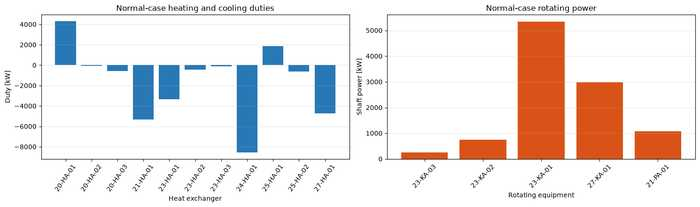

In [5]:
exchanger_tags = ['20-HA-01', '20-HA-02', '20-HA-03', '21-HA-01', '23-HA-01',
                  '23-HA-02', '23-HA-03', '24-HA-01', '25-HA-01', '25-HA-02', '27-HA-01']
def report_duty_kw(tag):
    item = report[tag]
    raw = item.get('data', {}).get('duty', item.get('duty', 0.0))
    return float(raw['value'] if isinstance(raw, dict) else raw) / 1000.0

duty_rows = [{'tag': tag, 'duty [kW]': report_duty_kw(tag)} for tag in exchanger_tags]
power_rows = [{'tag': tag, 'power [kW]': power_values[tag],
               'discharge temperature [C]': float(report[tag]['dischargeTemperature'])}
              for tag in compressor_tags]
power_rows.append({'tag': '21-PA-01', 'power [kW]': pump_power_kw,
                   'discharge temperature [C]': float(report['21-PA-01']['dischargeTemperature'])})
display(pd.DataFrame(duty_rows)); display(pd.DataFrame(power_rows))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar([row['tag'] for row in duty_rows], [row['duty [kW]'] for row in duty_rows], color='#2878B5')
axes[0].set(ylabel='Duty [kW]', xlabel='Heat exchanger', title='Normal-case heating and cooling duties')
axes[0].tick_params(axis='x', rotation=55); axes[0].grid(axis='y', alpha=0.3)
axes[1].bar([row['tag'] for row in power_rows], [row['power [kW]'] for row in power_rows], color='#D95319')
axes[1].set(ylabel='Shaft power [kW]', xlabel='Rotating equipment', title='Normal-case rotating power')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(axis='y', alpha=0.3)
fig.tight_layout(); plt.show()


**Figure discussion — duties and power.** Observation: the first export-compression stage and oil export pump are major electrical consumers, while the export aftercooler and oil cooler dominate cooling demand in the published base case. Mechanism: the gas is raised from first-stage pressure to 90 barg and then to 188.6 barg, and the stabilized oil is raised from LP-separator pressure to 60 barg. Engineering implication: compressor drivers, cooling-medium systems, electrical distribution, and oil-pump selection must use the multi-case envelope rather than the normal case. Recommendation: preserve at least 10% screening margin, then replace assumed efficiencies and heat-transfer coefficients with vendor and utility data.


## 3. Operating and accidental case matrices

Seven steady cases are executable process/design cases. The accidental cases are evaluated by the governed safety-scenario calculation because a label alone is not a dynamic compressor-trip, fire, or depressurization model.


In [6]:
STEADY_CASES = [
    ('minimum-turndown', 'MINIMUM_TURNDOWN', 0.60, 50.0, 31.5, 'Minimum stable production'),
    ('normal', 'NORMAL', 1.00, 60.0, 31.5, 'Published comparison case'),
    ('maximum-production', 'MAXIMUM_PRODUCTION', 1.20, 60.0, 31.5, 'Capacity and driver governing candidate'),
    ('cold-feed', 'AMBIENT_EXTREME', 1.00, 40.0, 31.5, 'Cold inlet and heating-duty check'),
    ('hot-feed', 'AMBIENT_EXTREME', 1.00, 75.0, 31.5, 'Hot inlet and cooling-duty check'),
    ('high-inlet-pressure', 'CUSTOM', 1.00, 60.0, 35.0, 'HP separator pressure envelope'),
    ('low-inlet-pressure', 'CUSTOM', 1.00, 60.0, 28.0, 'Recompression-power envelope'),
]
ACCIDENTAL_CASES = [
    ('blocked-gas-export', 'BLOCKED_OUTLET', '27-KA-01 / export piping'),
    ('cooling-failure', 'UTILITY_OR_COOLING_FAILURE', '23/24/25/27 coolers'),
    ('compressor-trip-settle-out', 'COMPRESSOR_TRIP_SETTLE_OUT', '23/27 compression trains'),
    ('fire-exposure', 'FIRE_EXPOSURE', 'separators and scrubbers'),
    ('simultaneous-blowdown', 'SIMULTANEOUS_BLOWDOWN', 'common flare interface'),
]
display(pd.DataFrame(STEADY_CASES, columns=['case', 'type', 'rate factor', 'feed C', 'HP sep barg', 'purpose']))
display(pd.DataFrame(ACCIDENTAL_CASES, columns=['scenario', 'type', 'scope']))


,case,type,rate factor,feed C,HP sep barg,purpose
0,minimum-turndown,MINIMUM_TURNDOWN,0.6,50.0,31.5,Minimum stable production
1,normal,NORMAL,1.0,60.0,31.5,Published comparison case
2,maximum-production,MAXIMUM_PRODUCTION,1.2,60.0,31.5,Capacity and driver governing candidate
3,cold-feed,AMBIENT_EXTREME,1.0,40.0,31.5,Cold inlet and heating-duty check
4,hot-feed,AMBIENT_EXTREME,1.0,75.0,31.5,Hot inlet and cooling-duty check
5,high-inlet-pressure,CUSTOM,1.0,60.0,35.0,HP separator pressure envelope
6,low-inlet-pressure,CUSTOM,1.0,60.0,28.0,Recompression-power envelope


,scenario,type,scope
0,blocked-gas-export,BLOCKED_OUTLET,27-KA-01 / export piping
1,cooling-failure,UTILITY_OR_COOLING_FAILURE,23/24/25/27 coolers
2,compressor-trip-settle-out,COMPRESSOR_TRIP_SETTLE_OUT,23/27 compression trains
3,fire-exposure,FIRE_EXPOSURE,separators and scrubbers
4,simultaneous-blowdown,SIMULTANEOUS_BLOWDOWN,common flare interface


In [7]:
NorsokBuilder = JClass('neqsim.process.engineering.NorsokOffshoreEngineeringBuilder')
DesignBuilder = JClass('neqsim.process.engineering.ProcessToEngineeringDesignBuilder')
DesignCase = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase')
DesignCaseInput = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase$Input')
Configurator = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase$Configurator')
EngineeringMetric = JClass('neqsim.process.engineering.designcase.EngineeringMetric')

project = NorsokBuilder.from_('Complete offshore process engineering study', process) \
    .projectId('OFFSHORE-PROCESS-STUDY').registerProposedInstruments(True).build().setRevision('A')
case_callbacks = []
for case_id, case_type, rate_factor, feed_temperature, hp_pressure, purpose in STEADY_CASES:
    params = dict(BASE); params['feed_rate_kmol_h'] *= rate_factor
    params['feed_temperature_C'] = feed_temperature; params['Psep1_barg'] = hp_pressure
    def configure(case_process, params=params):
        apply_case(case_process, params)
    proxy = JProxy(Configurator, dict={'configure': configure}); case_callbacks.append(proxy)
    case = DesignCase(case_id, purpose, getattr(DesignCase.Type, case_type), proxy)
    case.setCaseGroup('OPERATING-ENVELOPE').setApprovalStatus('REVIEW_REQUIRED')
    case.addInput(DesignCaseInput('feedRate', params['feed_rate_kmol_h'], 'kmol/hr', 'COLAB-COMPARISON-BASIS'))
    case.addInput(DesignCaseInput('feedTemperature', feed_temperature, 'C', 'SCREENING-ENVELOPE'))
    case.addInput(DesignCaseInput('firstStagePressure', hp_pressure, 'barg', 'SCREENING-ENVELOPE'))
    project.addDesignCase(case)

drivers = jdouble([500, 1000, 2000, 3000, 5000, 7500, 10000, 12500, 15000, 20000])
areas = jdouble([50, 100, 200, 400, 800, 1200, 1800, 2500, 4000])
volumes = jdouble([5, 10, 20, 40, 80, 120, 200, 300, 500])
cvs = jdouble([50, 100, 250, 500, 800, 1200, 2000])
builder = DesignBuilder.on(project).separatorBasis(750.0, 0.107, 180.0) \
    .exportLineLimits(20.0, 5.0).compressorDrivers(0.10, drivers)
builder.addInletCompressionExportSlice('20-VA-01', '23-KA-01', 'EXPORT-GAS-LINE', 'VLV-100', '20-PIT-001')
for tag in ['20-VA-02', '20-VA-03', '23-VG-01', '23-VG-02', '23-VG-03', '24-VG-01', '25-VG-01']:
    builder.addInventoryDesign(tag, 180.0, 0.70, volumes)
for tag in exchanger_tags:
    builder.addHeatExchangerDesign(tag, 500.0, 25.0, 0.15, areas)
builder.addPumpDesign('21-PA-01', 0.10, 3.0, drivers)
builder.addControlValveDesign('VLV-102', 70.0, 85.0, cvs)
for tag in ['23-KA-02', '23-KA-03', '27-KA-01']:
    builder.addRatedCapacity(tag, EngineeringMetric.compressorPower(tag),
        'driverRatedPower', 'kW', 0.10, drivers)
print('Executable cases:', project.getExecutableDesignCases().size())
print('Engineering design modules:', project.getEngineeringDesignModules().size())
print('23-PA-01 intermittent recycle-pump NPSH is screened separately below; '
      'zero-liquid steady cases are not a valid NPSH envelope basis.')


Executable cases: 7
Engineering design modules: 31
23-PA-01 intermittent recycle-pump NPSH is screened separately below; zero-liquid steady cases are not a valid NPSH envelope basis.


## 4. Closed process-to-engineering design loop

Each case runs on an isolated process copy. Discrete selections and continuous dimensions are applied to a separate designed process until physical variables, process values, and constraints stabilize. Depending on hardware, the full seven-case process may take several minutes.


In [8]:
Simulator = JClass('neqsim.process.engineering.ProcessToEngineeringSimulator')
simulation = Simulator.run(project, min(4, os.cpu_count() or 1))
loop = simulation.getEngineeringDesignLoopResult()
design_rows = []
for entry in loop.getState().getValues().entrySet():
    item = entry.getValue().toMap()
    design_rows.append({'variable': str(entry.getKey()), 'value': item.get('value'),
                        'unit': str(item.get('unit')), 'governing case': str(item.get('governingCaseId')),
                        'source module': str(item.get('sourceModule'))})
design_table = pd.DataFrame(design_rows).sort_values('variable').reset_index(drop=True)
print('Converged:', loop.isConverged(), 'iterations:', loop.getIterations().size(), loop.getTerminationReason())
display(design_table)
convergence_rows = []
for iteration in loop.getIterations():
    convergence = iteration.getConvergenceReport()
    convergence_rows.append({
        'iteration': iteration.getNumber(),
        'applied updates': iteration.getAppliedUpdateCount(),
        'maximum design change': iteration.getMaximumRelativeChange(),
        'maximum process change': convergence.getMaximumProcessValueRelativeChange(),
        'constraints satisfied': convergence.getSatisfiedConstraintCount(),
        'constraints evaluated': convergence.getConstraintCount(),
        'process stable': convergence.areProcessValuesStable(),
        'cases successful': convergence.areCaseRunsSuccessful(),
    })
convergence_table = pd.DataFrame(convergence_rows)
display(convergence_table)
print(convergence_table.to_string(index=False))
constraint_table = pd.DataFrame([
    {str(key): value for key, value in constraint.toMap().entrySet()}
    for constraint in loop.getIterations().get(loop.getIterations().size() - 1).getConstraintResults()
])
display(constraint_table)
print('Unsatisfied constraints:')
print(constraint_table.loc[~constraint_table['satisfied'].astype(bool)].to_string(index=False))
final_case_results = list(loop.getIterations().get(loop.getIterations().size() - 1)
                          .getCaseReport().getEnvelope().getCaseResults())
case_status_table = pd.DataFrame([
    {'case': str(result.getDesignCase().getId()), 'status': str(result.getStatus()),
     'converged': result.isConverged(), 'message': str(result.getMessage())}
    for result in final_case_results
])
display(case_status_table)
print(case_status_table.to_string(index=False))
metric_failure_rows = []
for result in final_case_results:
    for entry in result.getMetricResults().entrySet():
        metric_result = entry.getValue()
        if str(metric_result.getStatus()) == 'FAILED':
            detail = {str(key): value for key, value in metric_result.toMap().entrySet()}
            metric_failure_rows.append({'case': str(result.getDesignCase().getId()), **detail})
metric_failure_table = pd.DataFrame(metric_failure_rows)
print('Metric failures:')
print(metric_failure_table.to_string(index=False) if len(metric_failure_table) else 'none')
assert loop.isConverged()
assert not simulation.getCaseRunReport().getEnvelope().hasCaseFailures()


Converged: True iterations: 3 DESIGN_VARIABLES_PROCESS_VALUES_AND_CONSTRAINTS_CONVERGED


,variable,value,unit,governing case,source module
0,20-HA-01.areaUtilization,0.971505,fraction,cold-feed,32-heat-exchanger-design-20-HA-01
1,20-HA-01.preliminaryHeatTransferArea,1200.000000,m2,cold-feed,32-heat-exchanger-design-20-HA-01
2,20-HA-02.areaUtilization,0.199500,fraction,low-inlet-pressure,32-heat-exchanger-design-20-HA-02
3,20-HA-02.preliminaryHeatTransferArea,50.000000,m2,low-inlet-pressure,32-heat-exchanger-design-20-HA-02
4,20-HA-03.areaUtilization,0.642110,fraction,maximum-production,32-heat-exchanger-design-20-HA-03
...,...,...,...,...,...
68,EXPORT-GAS-LINE.predictedPressureGradient,0.042689,bar/km,maximum-production,20-line-hydraulics-EXPORT-GAS-LINE
69,VLV-100.governingOpening,50.106083,%,maximum-production,40-control-valve-design-VLV-100
70,VLV-100.selectedCv,400.000000,Cv,maximum-production,40-control-valve-design-VLV-100
71,VLV-102.governingOpening,48.113181,%,maximum-production,40-control-valve-design-VLV-102


,iteration,applied updates,maximum design change,maximum process change,constraints satisfied,constraints evaluated,process stable,cases successful
0,1,73,inf,inf,34,34,False,True
1,2,4,37.90625,0.240376,34,34,False,True
2,3,0,0.00000,0.000000,34,34,True,True


 iteration  applied updates  maximum design change  maximum process change  constraints satisfied  constraints evaluated  process stable  cases successful
         1               73                    inf                     inf                     34                     34           False              True
         2                4               37.90625                0.240376                     34                     34           False              True
         3                0                0.00000                0.000000                     34                     34            True              True


,id,description,satisfied,actual,limit,unit,comparison,margin
0,20-VA-01.gas-capacity,Gas velocity below capacity,1,0.529784,0.544548,m/s,MAXIMUM,0.014764
1,20-VA-01.retention,Minimum liquid retention time,1,181.577047,180.000000,s,MINIMUM,1.577047
2,20-VA-02.working-time,Minimum working time,1,211.620679,180.000000,s,MINIMUM,31.620679
3,20-VA-03.working-time,Minimum working time,1,235.011185,180.000000,s,MINIMUM,55.011185
4,23-VG-01.working-time,Minimum working time,1,267.051775,180.000000,s,MINIMUM,87.051775
5,23-VG-02.working-time,Minimum working time,1,254.042573,180.000000,s,MINIMUM,74.042573
6,23-VG-03.working-time,Minimum working time,1,199.420816,180.000000,s,MINIMUM,19.420816
7,24-VG-01.working-time,Minimum working time,1,223.407281,180.000000,s,MINIMUM,43.407281
8,25-VG-01.working-time,Minimum working time,1,180.424467,180.000000,s,MINIMUM,0.424467
9,EXPORT-GAS-LINE.velocity-limit,Maximum design velocity,1,1.236802,20.000000,m/s,MAXIMUM,18.763198


Unsatisfied constraints:
Empty DataFrame
Columns: [id, description, satisfied, actual, limit, unit, comparison, margin]
Index: []


,case,status,converged,message
0,cold-feed,CALCULATED,True,
1,high-inlet-pressure,CALCULATED,True,
2,hot-feed,CALCULATED,True,
3,low-inlet-pressure,CALCULATED,True,
4,maximum-production,CALCULATED,True,
5,minimum-turndown,CALCULATED,True,
6,normal,CALCULATED,True,


               case     status  converged message
          cold-feed CALCULATED       True        
high-inlet-pressure CALCULATED       True        
           hot-feed CALCULATED       True        
 low-inlet-pressure CALCULATED       True        
 maximum-production CALCULATED       True        
   minimum-turndown CALCULATED       True        
             normal CALCULATED       True        
Metric failures:
none


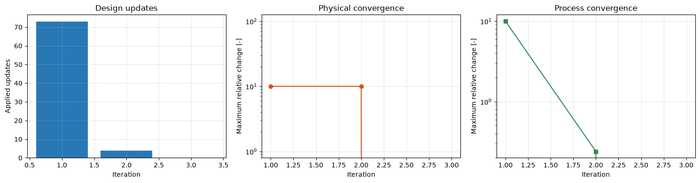

In [9]:
iterations = list(loop.getIterations())
x = [item.getNumber() for item in iterations]
updates = [item.getAppliedUpdateCount() for item in iterations]
physical = [min(item.getMaximumRelativeChange(), 10.0) for item in iterations]
process_change = [min(item.getConvergenceReport().getMaximumProcessValueRelativeChange(), 10.0) for item in iterations]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
axes[0].bar(x, updates, color='#2878B5'); axes[0].set(xlabel='Iteration', ylabel='Applied updates', title='Design updates')
axes[1].semilogy(x, physical, marker='o', color='#D95319'); axes[1].set(xlabel='Iteration', ylabel='Maximum relative change [-]', title='Physical convergence')
axes[2].semilogy(x, process_change, marker='s', color='#2E8B57'); axes[2].set(xlabel='Iteration', ylabel='Maximum relative change [-]', title='Process convergence')
for ax in axes: ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()


**Figure discussion — convergence.** Observation: the first pass selects preliminary geometry and ratings; later passes re-run the connected process with those selections until no material update remains. Mechanism: line diameter, separator size, heat-transfer area, valve Cv, and driver ratings alter pressure drop or equipment state and can move the governing case. Engineering implication: a one-pass datasheet export can be internally inconsistent. Recommendation: review every unsatisfied constraint and governing-case change, and retain the iteration evidence in the package.


,case,compressor power [kW],successful
0,cold-feed,9323.706322,True
1,high-inlet-pressure,8809.450454,True
2,hot-feed,9323.706322,True
3,low-inlet-pressure,9965.964118,True
4,maximum-production,11197.285462,True
5,minimum-turndown,5565.129675,True
6,normal,9323.706322,True


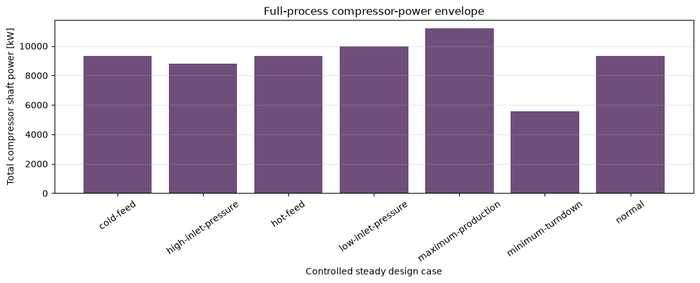

In [10]:
case_results = list(simulation.getCaseRunReport().getEnvelope().getCaseResults())
envelope_rows = []
for item in case_results:
    values = item.getValues()
    rotating = sum(float(values.get(tag + '.power') or 0.0) for tag in compressor_tags)
    envelope_rows.append({'case': str(item.getDesignCase().getId()), 'compressor power [kW]': rotating,
                          'successful': str(item.getStatus()) == 'CALCULATED'})
envelope_table = pd.DataFrame(envelope_rows)
display(envelope_table)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(envelope_table['case'], envelope_table['compressor power [kW]'], color='#6F4E7C')
ax.set(xlabel='Controlled steady design case', ylabel='Total compressor shaft power [kW]',
       title='Full-process compressor-power envelope')
ax.tick_params(axis='x', rotation=35); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); plt.show()


**Figure discussion — case envelope.** Observation: the maximum-rate or low-inlet-pressure case normally governs total compression power, while temperature extremes govern different exchanger duties. Mechanism: recompression ratio and gas volumetric flow change simultaneously across the multi-stage train. Engineering implication: no single “design case” controls every equipment item. Recommendation: retain the governing case on each selected variable and verify driver, exchanger, line, valve, and vessel margins independently.


## 5. Discipline calculations for every equipment family in this process

The design loop gives connected, multi-case selections. The following typed calculations expose the underlying preliminary process/mechanical results for all separators and scrubbers, compressors, pumps, and exchangers. Screening assumptions such as surrogate surge/choke flow, U-value, NPSH required, corrosion allowance, and MDMT are deliberately visible.


In [11]:
Context = JClass('neqsim.process.engineering.calculation.EngineeringCalculationContext')
context = Context.builder().designCaseId('maximum-production').build()
EquipmentInput = JClass('neqsim.process.engineering.calculation.EquipmentDesignCalculations$Input')
SepCalc = JClass('neqsim.process.engineering.calculation.EquipmentDesignCalculations$Separator')
CompCalc = JClass('neqsim.process.engineering.calculation.EquipmentDesignCalculations$Compressor')
PumpCalc = JClass('neqsim.process.engineering.calculation.EquipmentDesignCalculations$Pump')
HxCalc = JClass('neqsim.process.engineering.calculation.EquipmentDesignCalculations$HeatExchanger')

def map_row(tag, family, result):
    row = {'tag': tag, 'family': family, 'status': str(result.getStatus())}
    if result.getValue() is not None:
        row.update({str(k): v for k, v in result.getValue().toMap().entrySet()})
    return row

separator_tags = ['20-VA-01', '20-VA-02', '20-VA-03', '23-VG-01', '23-VG-02',
                  '23-VG-03', '24-VG-01', '25-VG-01']
equipment_rows = []
for tag in separator_tags:
    unit = process.getUnit(tag); gas = unit.getGasOutStream()
    liquid = unit.getOilOutStream() if tag.startswith('20-VA') else unit.getLiquidOutStream()
    gas.getFluid().initProperties(); liquid.getFluid().initProperties()
    inputs = EquipmentInput.builder(tag, 'maximum-production', 'COLAB-COMPARISON-BASIS') \
        .value('gasFlowM3s', max(gas.getFlowRate('m3/sec'), 1.0e-8)) \
        .value('liquidFlowM3s', max(liquid.getFlowRate('m3/sec'), 1.0e-8)) \
        .value('gasDensityKgM3', max(gas.getFluid().getDensity('kg/m3'), 0.1)) \
        .value('liquidDensityKgM3', max(liquid.getFluid().getDensity('kg/m3'), 100.0)).build()
    equipment_rows.append(map_row(tag, 'separator', SepCalc().calculate(inputs, context)))

for tag in compressor_tags:
    unit = process.getUnit(tag); flow = max(unit.getInletStream().getFlowRate('m3/sec'), 1.0e-8)
    inputs = EquipmentInput.builder(tag, 'maximum-production', 'SCREENING-MAP-BASIS') \
        .value('operatingFlowM3s', flow).value('surgeFlowM3s', 0.70 * flow) \
        .value('chokeFlowM3s', 1.40 * flow).value('shaftPowerKw', unit.getPower('kW')).build()
    equipment_rows.append(map_row(tag, 'compressor', CompCalc().calculate(inputs, context)))

for tag in ['21-PA-01', '23-PA-01']:
    unit = process.getUnit(tag); inlet = unit.getInletStream(); inlet.getFluid().initProperties()
    rho = max(inlet.getFluid().getDensity('kg/m3'), 100.0)
    head = max((unit.getOutletStream().getPressure('bara') - inlet.getPressure('bara')) * 1.0e5 / rho / 9.80665, 1.0)
    inputs = EquipmentInput.builder(tag, 'maximum-production', 'SCREENING-PUMP-BASIS') \
        .value('flowM3s', max(inlet.getFlowRate('m3/sec'), 1.0e-8)).value('headM', head) \
        .value('npshaM', 8.0).value('npshrM', 4.0).value('shaftPowerKw', unit.getPower() / 1000.0).build()
    equipment_rows.append(map_row(tag, 'pump', PumpCalc().calculate(inputs, context)))

for tag in exchanger_tags:
    inputs = EquipmentInput.builder(tag, 'maximum-production', 'SCREENING-THERMAL-BASIS') \
        .value('dutyKw', max(abs(report_duty_kw(tag)), 1.0e-6)).value('overallU_WPerM2K', 500.0) \
        .value('correctedLmtdK', 25.0).build()
    equipment_rows.append(map_row(tag, 'heat exchanger', HxCalc().calculate(inputs, context)))
equipment_design_table = pd.DataFrame(equipment_rows)
display(equipment_design_table)


,tag,family,status,equipmentTag,governingCaseId,designBasisReference,values,constraints,allConstraintsSatisfied,approvalStatus
0,20-VA-01,SEPARATOR_OR_SCRUBBER,CALCULATED_REVIEW_REQUIRED,20-VA-01,maximum-production,COLAB-COMPARISON-BASIS,"{'insideDiameterM': 2.242991523158419, 'tangen...","{'gasCapacity': True, 'retention': True, 'leve...",1,REVIEW_REQUIRED
1,20-VA-02,SEPARATOR_OR_SCRUBBER,CALCULATED_REVIEW_REQUIRED,20-VA-02,maximum-production,COLAB-COMPARISON-BASIS,"{'insideDiameterM': 0.9253505103511713, 'tange...","{'gasCapacity': True, 'retention': True, 'leve...",1,REVIEW_REQUIRED
2,20-VA-03,SEPARATOR_OR_SCRUBBER,CALCULATED_REVIEW_REQUIRED,20-VA-03,maximum-production,COLAB-COMPARISON-BASIS,"{'insideDiameterM': 0.9316848446148663, 'tange...","{'gasCapacity': True, 'retention': True, 'leve...",1,REVIEW_REQUIRED
3,23-VG-01,SEPARATOR_OR_SCRUBBER,CALCULATED_REVIEW_REQUIRED,23-VG-01,maximum-production,COLAB-COMPARISON-BASIS,"{'insideDiameterM': 2.5065200629369335, 'tange...","{'gasCapacity': True, 'retention': True, 'leve...",1,REVIEW_REQUIRED
4,23-VG-02,SEPARATOR_OR_SCRUBBER,CALCULATED_REVIEW_REQUIRED,23-VG-02,maximum-production,COLAB-COMPARISON-BASIS,"{'insideDiameterM': 1.178883312284309, 'tangen...","{'gasCapacity': True, 'retention': True, 'leve...",1,REVIEW_REQUIRED
5,23-VG-03,SEPARATOR_OR_SCRUBBER,CALCULATED_REVIEW_REQUIRED,23-VG-03,maximum-production,COLAB-COMPARISON-BASIS,"{'insideDiameterM': 0.9805627204556924, 'tange...","{'gasCapacity': True, 'retention': True, 'leve...",1,REVIEW_REQUIRED
6,24-VG-01,SEPARATOR_OR_SCRUBBER,CALCULATED_REVIEW_REQUIRED,24-VG-01,maximum-production,COLAB-COMPARISON-BASIS,"{'insideDiameterM': 1569.9201451902045, 'tange...","{'gasCapacity': True, 'retention': True, 'leve...",1,REVIEW_REQUIRED
7,25-VG-01,SEPARATOR_OR_SCRUBBER,CALCULATED_REVIEW_REQUIRED,25-VG-01,maximum-production,COLAB-COMPARISON-BASIS,"{'insideDiameterM': 1.928178238169769, 'tangen...","{'gasCapacity': True, 'retention': True, 'leve...",1,REVIEW_REQUIRED
8,23-KA-03,COMPRESSOR,CALCULATED_REVIEW_REQUIRED,23-KA-03,maximum-production,SCREENING-MAP-BASIS,"{'driverRequiredPowerKw': 280.699825338183, 's...","{'surgeMargin': True, 'chokeMargin': True, 'ma...",1,REVIEW_REQUIRED
9,23-KA-02,COMPRESSOR,CALCULATED_REVIEW_REQUIRED,23-KA-02,maximum-production,SCREENING-MAP-BASIS,"{'driverRequiredPowerKw': 825.8078869513207, '...","{'surgeMargin': True, 'chokeMargin': True, 'ma...",1,REVIEW_REQUIRED


In [12]:
Piping = 'neqsim.process.engineering.piping.PipingNetworkDesignCalculation'
Candidate = JClass(Piping + '$Candidate'); HydraulicCase = JClass(Piping + '$Case')
Segment = JClass(Piping + '$Segment'); NetworkInput = JClass(Piping + '$Input')
ArrayList = JClass('java.util.ArrayList'); LinkedHashMap = JClass('java.util.LinkedHashMap')
candidates = ArrayList()
for name, diameter in [('6in', 0.154), ('8in', 0.203), ('10in', 0.254), ('12in', 0.303), ('16in', 0.394), ('20in', 0.489)]:
    candidates.add(Candidate(name, '40', diameter, 250.0))
gas_flow = max(process.getUnit('EXPORT-GAS-LINE').getInletStream().getFlowRate('m3/sec'), 1.0e-6)
oil_flow = max(process.getUnit('EXPORT-OIL-LINE').getInletStream().getFlowRate('m3/sec'), 1.0e-6)
gas_segment = Segment('EXPORT-GAS-LINE', True, False, 2000.0, 0.0, 10.0, 1.0, 0.0) \
    .addCase(HydraulicCase('maximum-production', 1.20 * gas_flow, 0.10, 0.20, 190.0, 40.0))
oil_segment = Segment('EXPORT-OIL-LINE', True, False, 2000.0, 0.0, 5.0, 1.0, 0.0) \
    .addCase(HydraulicCase('maximum-production', 1.20 * oil_flow, 0.10, 0.20, 61.0, 49.0))
segments = ArrayList(); segments.add(gas_segment); segments.add(oil_segment)
demands = LinkedHashMap(); demands.put('gas export', 1.20 * gas_flow); demands.put('oil export', 1.20 * oil_flow)
rules = JClass('neqsim.process.engineering.piping.PipingRulePack').norsokP0022023Ac2024()
network = JClass(Piping)().calculate(NetworkInput('terminal-export-network', rules, candidates, segments, demands), context)
network_table = pd.DataFrame([{'segment': str(k), **{str(a): b for a, b in v.entrySet()}}
                              for k, v in network.getValue().toMap().get('selections').entrySet()])
display(network_table)


,segment,governingCaseId,maximumVelocityMPerS,minimumVelocityMPerS,maximumPressureGradientBarPerKm,maximumPressureDropBar,maximumReynoldsNumber,maximumDarcyFrictionFactor,simultaneousDemandGroup,simultaneousDemandM3s,...,erosionVelocityLimitMPerS,erosionVelocitySatisfied,noiseScreenRequired,vibrationScreenRequired,transientInventoryM3,liquidSlugAssessmentRequired,reliefInletLossSatisfied,allConstraintsSatisfied,candidate,governingStatus
0,EXPORT-GAS-LINE,maximum-production,9.543315,9.543315,0.204334,0.408669,0.0,0.0,,0.0,...,15.811388,1,0,0,37.253006,1,1,1,"{'nominalSize': '6in', 'schedule': '40', 'insi...",CALCULATED_REVIEW_REQUIRED
1,EXPORT-OIL-LINE,maximum-production,14.266397,14.266397,0.196734,0.393468,0.0,0.0,,0.0,...,14.285714,1,0,0,37.253006,1,1,1,"{'nominalSize': '6in', 'schedule': '40', 'insi...",CALCULATED_REVIEW_REQUIRED


In [13]:
ValveInput = JClass('neqsim.process.engineering.calculation.ValveInstrumentDesignCalculations$ValveInput')
ValveCalc = JClass('neqsim.process.engineering.calculation.ValveInstrumentDesignCalculations$Valve')
Failure = JClass('neqsim.process.engineering.calculation.ValveInstrumentDesignCalculations$FailurePosition')
valve_rows = []
for tag, selected_cv in [('VLV-100', 800.0), ('VLV-102', 600.0)]:
    valve = process.getUnit(tag); inlet = valve.getInletStream(); outlet = valve.getOutletStream()
    inlet.getFluid().initProperties()
    result = ValveCalc().calculate(ValveInput(tag, 'maximum-production', 0.8 * selected_cv, selected_cv,
        70.0, inlet.getPressure('bara'), outlet.getPressure('bara'), 1.0, 50.0,
        max(inlet.getFluid().getDensity('kg/m3'), 1.0), inlet.getFlowRate('kg/sec'),
        8.0, 10.0, Failure.HAZOP_INPUT_REQUIRED), context)
    valve_rows.append(map_row(tag, 'valve', result))

InstrumentInput = JClass('neqsim.process.engineering.calculation.ValveInstrumentDesignCalculations$InstrumentInput')
InstrumentCalc = JClass('neqsim.process.engineering.calculation.ValveInstrumentDesignCalculations$Instrument')
instrument_rows = []
for tag, low, high, upper in [('20-PIT-001', 28.0, 35.5, 40.0), ('20-TIT-001', 40.0, 75.0, 100.0),
                              ('23-PIT-001', 8.0, 35.0, 40.0), ('25-TIT-001', 5.0, 20.0, 50.0),
                              ('27-PIT-001', 180.0, 200.0, 250.0), ('21-PIT-001', 55.0, 65.0, 100.0)]:
    result = InstrumentCalc().calculate(InstrumentInput(tag, 'operating-envelope', low, high, 0.0, upper,
        0.005, 1.0, 0.5, 8.0, 15.0, 2.0, 30.0), context)
    instrument_rows.append(map_row(tag, 'instrument', result))
display(pd.DataFrame(valve_rows)); display(pd.DataFrame(instrument_rows))


,tag,family,status,governingCaseId,requiredCv,selectedCv,predictedOpeningPercent,chokedFlowScreen,flashingScreen,cavitationIndex,noiseScreenDbA,actuatorForceIndex,strokeTimeSatisfied,failurePositionProposal,characteristic,leakageClass,approvalStatus
0,VLV-100,valve,CALCULATED_REVIEW_REQUIRED,maximum-production,640.0,800.0,56.0,0,0,1.370141,105.617576,18400.0,1,HAZOP_INPUT_REQUIRED,EQUAL_PERCENTAGE_PRELIMINARY,PROJECT_INPUT_REQUIRED,REVIEW_REQUIRED
1,VLV-102,valve,CALCULATED_REVIEW_REQUIRED,maximum-production,480.0,600.0,56.0,0,0,1.335542,99.724947,3600.0,1,HAZOP_INPUT_REQUIRED,EQUAL_PERCENTAGE_PRELIMINARY,PROJECT_INPUT_REQUIRED,REVIEW_REQUIRED


,tag,family,status,governingCaseId,calibratedSpan,measurementUncertainty,rangeCoversProcessEnvelope,totalSafetyResponseSeconds,processSafetyTimeMarginSeconds,preliminaryControllerGain,preliminaryIntegralTimeSeconds,tapAndImpulseLineStatus,thermowellStatus,permissiveResetRestartLogic,standards,approvalStatus
0,20-PIT-001,instrument,CALCULATED_REVIEW_REQUIRED,operating-envelope,40.0,0.20,1,9.5,5.5,0.25,30.0,PROJECT_LAYOUT_INPUT_REQUIRED,WAKE_FREQUENCY_REVIEW_IF_APPLICABLE,CAUSE_AND_EFFECT_INPUT_REQUIRED,ANSI/ISA-5.1-2024; NORSOK I-001:2025+AC:2026; ...,REVIEW_REQUIRED
1,20-TIT-001,instrument,CALCULATED_REVIEW_REQUIRED,operating-envelope,100.0,0.50,1,9.5,5.5,0.25,30.0,PROJECT_LAYOUT_INPUT_REQUIRED,WAKE_FREQUENCY_REVIEW_IF_APPLICABLE,CAUSE_AND_EFFECT_INPUT_REQUIRED,ANSI/ISA-5.1-2024; NORSOK I-001:2025+AC:2026; ...,REVIEW_REQUIRED
2,23-PIT-001,instrument,CALCULATED_REVIEW_REQUIRED,operating-envelope,40.0,0.20,1,9.5,5.5,0.25,30.0,PROJECT_LAYOUT_INPUT_REQUIRED,WAKE_FREQUENCY_REVIEW_IF_APPLICABLE,CAUSE_AND_EFFECT_INPUT_REQUIRED,ANSI/ISA-5.1-2024; NORSOK I-001:2025+AC:2026; ...,REVIEW_REQUIRED
3,25-TIT-001,instrument,CALCULATED_REVIEW_REQUIRED,operating-envelope,50.0,0.25,1,9.5,5.5,0.25,30.0,PROJECT_LAYOUT_INPUT_REQUIRED,WAKE_FREQUENCY_REVIEW_IF_APPLICABLE,CAUSE_AND_EFFECT_INPUT_REQUIRED,ANSI/ISA-5.1-2024; NORSOK I-001:2025+AC:2026; ...,REVIEW_REQUIRED
4,27-PIT-001,instrument,CALCULATED_REVIEW_REQUIRED,operating-envelope,250.0,1.25,1,9.5,5.5,0.25,30.0,PROJECT_LAYOUT_INPUT_REQUIRED,WAKE_FREQUENCY_REVIEW_IF_APPLICABLE,CAUSE_AND_EFFECT_INPUT_REQUIRED,ANSI/ISA-5.1-2024; NORSOK I-001:2025+AC:2026; ...,REVIEW_REQUIRED
5,21-PIT-001,instrument,CALCULATED_REVIEW_REQUIRED,operating-envelope,100.0,0.50,1,9.5,5.5,0.25,30.0,PROJECT_LAYOUT_INPUT_REQUIRED,WAKE_FREQUENCY_REVIEW_IF_APPLICABLE,CAUSE_AND_EFFECT_INPUT_REQUIRED,ANSI/ISA-5.1-2024; NORSOK I-001:2025+AC:2026; ...,REVIEW_REQUIRED


In [14]:
Safety = 'neqsim.process.engineering.safety.SafetyScenarioEngineCalculation'
Scenario = JClass(Safety + '$Scenario'); ScenarioType = JClass(Safety + '$Type')
Credibility = JClass(Safety + '$Credibility'); FluidModel = JClass(Safety + '$FluidModel')
scenarios = ArrayList()
scenario_inputs = [
    ('blocked-gas-export', '27-KA-01', ScenarioType.BLOCKED_OUTLET, FluidModel.GAS, 'GAS-TRAIN', 30.0, 200.0, 1.287, -20.0),
    ('cooling-failure', '24-VG-01', ScenarioType.UTILITY_OR_COOLING_FAILURE, FluidModel.GAS, 'GAS-TRAIN', 20.0, 100.0, 0.785, -20.0),
    ('compressor-trip', '23-KA-01', ScenarioType.COMPRESSOR_TRIP_SETTLE_OUT, FluidModel.GAS, 'GAS-TRAIN', 15.0, 100.0, 0.503, -35.0),
    ('fire-hp-separator', '20-VA-01', ScenarioType.FIRE_EXPOSURE, FluidModel.TWO_PHASE, 'FIRE-ZONE-20', 25.0, 40.0, 1.287, -20.0),
    ('blocked-oil-export', '21-PA-01', ScenarioType.BLOCKED_OUTLET, FluidModel.LIQUID, 'LIQUID-TRAIN', 12.0, 70.0, 0.503, 0.0),
    ('simultaneous-blowdown', '24-VG-01', ScenarioType.SIMULTANEOUS_BLOWDOWN, FluidModel.GAS, 'BLOWDOWN-ALL', 45.0, 100.0, 1.838, -46.0),
]
for sid, tag, stype, fluid_model, group, mass, pressure, area, minimum_temperature in scenario_inputs:
    scenarios.add(Scenario(sid, tag, stype, Credibility.CREDIBLE, fluid_model, group,
        'SCREENING-CREDIBILITY-ASSUMPTION-NOT-HAZOP-APPROVED', mass, pressure, area,
        2.0, 5.0, 1.0, minimum_temperature))
orifices = jdouble([0.110, 0.196, 0.307, 0.503, 0.785, 1.287, 1.838, 2.853, 4.34])
safety = JClass(Safety)().calculate(JClass(Safety + '$Input')('full-process-safety-screen', scenarios,
    orifices, 3.0, 10.0, 120.0, -46.0), context)
safety_map = safety.getValue().toMap()
safety_table = pd.DataFrame([{str(k): v for k, v in row.entrySet()}
                             for row in safety_map.get('scenarios').values()])
display(safety_table)
display(pd.DataFrame([{'concurrency group': str(k), 'load [kg/s]': v}
                      for k, v in safety_map.get('concurrencyGroupLoadsKgS').entrySet()]))


,scenarioId,protectedEquipmentTag,type,fluidModel,hazardReviewReference,requiredAreaIn2,selectedApiOrificeAreaIn2,inletLossSatisfied,builtUpBackPressureSatisfied,superimposedBackPressureBarg,psvStabilityReviewRequired,minimumTemperatureSatisfied,concurrencyGroup,status
0,blocked-gas-export,27-KA-01,BLOCKED_OUTLET,GAS,SCREENING-CREDIBILITY-ASSUMPTION-NOT-HAZOP-APP...,1.287,1.287,1,1,1.0,1,1,GAS-TRAIN,CALCULATED_REVIEW_REQUIRED
1,cooling-failure,24-VG-01,UTILITY_OR_COOLING_FAILURE,GAS,SCREENING-CREDIBILITY-ASSUMPTION-NOT-HAZOP-APP...,0.785,0.785,1,1,1.0,1,1,GAS-TRAIN,CALCULATED_REVIEW_REQUIRED
2,compressor-trip,23-KA-01,COMPRESSOR_TRIP_SETTLE_OUT,GAS,SCREENING-CREDIBILITY-ASSUMPTION-NOT-HAZOP-APP...,0.503,0.503,1,1,1.0,1,1,GAS-TRAIN,CALCULATED_REVIEW_REQUIRED
3,fire-hp-separator,20-VA-01,FIRE_EXPOSURE,TWO_PHASE,SCREENING-CREDIBILITY-ASSUMPTION-NOT-HAZOP-APP...,1.287,1.287,1,1,1.0,1,1,FIRE-ZONE-20,CALCULATED_REVIEW_REQUIRED
4,blocked-oil-export,21-PA-01,BLOCKED_OUTLET,LIQUID,SCREENING-CREDIBILITY-ASSUMPTION-NOT-HAZOP-APP...,0.503,0.503,1,1,1.0,1,1,LIQUID-TRAIN,CALCULATED_REVIEW_REQUIRED
5,simultaneous-blowdown,24-VG-01,SIMULTANEOUS_BLOWDOWN,GAS,SCREENING-CREDIBILITY-ASSUMPTION-NOT-HAZOP-APP...,1.838,1.838,1,1,1.0,1,1,BLOWDOWN-ALL,CALCULATED_REVIEW_REQUIRED


,concurrency group,load [kg/s]
0,GAS-TRAIN,65.0
1,FIRE-ZONE-20,25.0
2,LIQUID-TRAIN,12.0
3,BLOWDOWN-ALL,45.0


In [15]:
MaterialInput = JClass('neqsim.process.engineering.calculation.MaterialsMechanicalDesignCalculations$MaterialInput')
MaterialCalc = JClass('neqsim.process.engineering.calculation.MaterialsMechanicalDesignCalculations$MaterialSelection')
MechanicalInput = JClass('neqsim.process.engineering.calculation.MaterialsMechanicalDesignCalculations$MechanicalInput')
MechanicalCalc = JClass('neqsim.process.engineering.calculation.MaterialsMechanicalDesignCalculations$PreliminaryMechanical')
materials_rows, mechanical_rows = [], []
for tag in separator_tags:
    operating_pressure = process.getUnit(tag).getInletStreams().get(0).getPressure('bara')
    material = MaterialCalc().calculate(MaterialInput(tag, 'operating-envelope', 0.0159, 0.0, 100.0,
        True, False, 70.0, 100.0, -46.0, 1.10 * operating_pressure, 3.0, 25.0,
        'marine offshore external environment'), context)
    materials_rows.append(map_row(tag, 'materials', material))
    design = design_table[design_table['variable'].str.startswith(tag + '.')]
    diameter = float(design.loc[design['variable'].str.contains('insideDiameter'), 'value'].iloc[0]) if design['variable'].str.contains('insideDiameter').any() else 2.0
    length = float(design.loc[design['variable'].str.contains('tangentLength'), 'value'].iloc[0]) if design['variable'].str.contains('tangentLength').any() else 6.0
    mechanical = MechanicalCalc().calculate(MechanicalInput(tag, 'operating-envelope', operating_pressure,
        1.10 * operating_pressure, diameter, length, 138.0, 0.85, 3.0, -46.0, 0.10), context)
    mechanical_rows.append(map_row(tag, 'mechanical', mechanical))
display(pd.DataFrame(materials_rows)); display(pd.DataFrame(mechanical_rows))


,tag,family,status,equipmentTag,governingCaseId,preliminaryMaterialClass,degradationMechanisms,corrosionAllowanceMm,designLifeYears,designPressureBara,designTemperatureC,minimumDesignMetalTemperatureC,standard,finalMetallurgyApproved,approvalStatus
0,20-VA-01,materials,CALCULATED_REVIEW_REQUIRED,20-VA-01,operating-envelope,CARBON_STEEL_WITH_CORROSION_ALLOWANCE,"[WET_CO2_CORROSION, EXTERNAL_MARINE_CORROSION_...",3.0,25.0,35.764575,100.0,-46.0,NORSOK M-001:2025; ISO 15156 project-applicabl...,0,REVIEW_REQUIRED
1,20-VA-02,materials,CALCULATED_REVIEW_REQUIRED,20-VA-02,operating-envelope,CARBON_STEEL_WITH_CORROSION_ALLOWANCE,"[WET_CO2_CORROSION, EXTERNAL_MARINE_CORROSION_...",3.0,25.0,9.914575,100.0,-46.0,NORSOK M-001:2025; ISO 15156 project-applicabl...,0,REVIEW_REQUIRED
2,20-VA-03,materials,CALCULATED_REVIEW_REQUIRED,20-VA-03,operating-envelope,CARBON_STEEL_WITH_CORROSION_ALLOWANCE,"[WET_CO2_CORROSION, EXTERNAL_MARINE_CORROSION_...",3.0,25.0,2.764575,100.0,-46.0,NORSOK M-001:2025; ISO 15156 project-applicabl...,0,REVIEW_REQUIRED
3,23-VG-01,materials,CALCULATED_REVIEW_REQUIRED,23-VG-01,operating-envelope,CARBON_STEEL_WITH_CORROSION_ALLOWANCE,"[WET_CO2_CORROSION, EXTERNAL_MARINE_CORROSION_...",3.0,25.0,35.434575,100.0,-46.0,NORSOK M-001:2025; ISO 15156 project-applicabl...,0,REVIEW_REQUIRED
4,23-VG-02,materials,CALCULATED_REVIEW_REQUIRED,23-VG-02,operating-envelope,CARBON_STEEL_WITH_CORROSION_ALLOWANCE,"[WET_CO2_CORROSION, EXTERNAL_MARINE_CORROSION_...",3.0,25.0,8.814575,100.0,-46.0,NORSOK M-001:2025; ISO 15156 project-applicabl...,0,REVIEW_REQUIRED
5,23-VG-03,materials,CALCULATED_REVIEW_REQUIRED,23-VG-03,operating-envelope,CARBON_STEEL_WITH_CORROSION_ALLOWANCE,"[WET_CO2_CORROSION, EXTERNAL_MARINE_CORROSION_...",3.0,25.0,2.214575,100.0,-46.0,NORSOK M-001:2025; ISO 15156 project-applicabl...,0,REVIEW_REQUIRED
6,24-VG-01,materials,CALCULATED_REVIEW_REQUIRED,24-VG-01,operating-envelope,CARBON_STEEL_WITH_CORROSION_ALLOWANCE,"[WET_CO2_CORROSION, EXTERNAL_MARINE_CORROSION_...",3.0,25.0,99.014575,100.0,-46.0,NORSOK M-001:2025; ISO 15156 project-applicabl...,0,REVIEW_REQUIRED
7,25-VG-01,materials,CALCULATED_REVIEW_REQUIRED,25-VG-01,operating-envelope,CARBON_STEEL_WITH_CORROSION_ALLOWANCE,"[WET_CO2_CORROSION, EXTERNAL_MARINE_CORROSION_...",3.0,25.0,98.464575,100.0,-46.0,NORSOK M-001:2025; ISO 15156 project-applicabl...,0,REVIEW_REQUIRED


,tag,family,status,equipmentTag,governingCaseId,designPressureBara,designTemperatureC,preliminaryMawpBarg,requiredStructuralThicknessMm,preliminaryNominalThicknessMm,corrosionAllowanceMm,minimumDesignMetalTemperatureC,preliminaryNozzleInsideDiameterM,approximateShellMassKg,footprintLengthM,footprintWidthM,insulationRequired,heatTracingRequired,codeDesignComplete,approvalStatus
0,20-VA-01,mechanical,CALCULATED_REVIEW_REQUIRED,20-VA-01,operating-envelope,32.51325,35.764575,32.301338,34.117494,38.0,3.0,-46.0,0.159577,48613.986469,23.25,3.75,0,0,0,REVIEW_REQUIRED
1,20-VA-02,mechanical,CALCULATED_REVIEW_REQUIRED,20-VA-02,operating-envelope,9.01325,9.914575,8.176658,6.848142,10.0,3.0,-46.0,0.159577,2959.380280,8.00,3.00,0,0,0,REVIEW_REQUIRED
2,20-VA-03,mechanical,CALCULATED_REVIEW_REQUIRED,20-VA-03,operating-envelope,2.51325,2.764575,2.343188,1.279754,5.0,3.0,-46.0,0.159577,1479.690140,8.00,3.00,0,1,0,REVIEW_REQUIRED
3,23-VG-01,mechanical,CALCULATED_REVIEW_REQUIRED,23-VG-01,operating-envelope,32.21325,35.434575,32.301338,27.029837,31.0,3.0,-46.0,0.159577,9174.078867,8.00,3.00,0,0,0,REVIEW_REQUIRED
4,23-VG-02,mechanical,CALCULATED_REVIEW_REQUIRED,23-VG-02,operating-envelope,8.01325,8.814575,7.012754,5.989049,9.0,3.0,-46.0,0.159577,2663.442252,8.00,3.00,0,0,0,REVIEW_REQUIRED
5,23-VG-03,mechanical,CALCULATED_REVIEW_REQUIRED,23-VG-03,operating-envelope,2.01325,2.214575,1.172297,0.852951,4.0,3.0,-46.0,0.159577,1183.752112,8.00,3.00,0,1,0,REVIEW_REQUIRED
6,24-VG-01,mechanical,CALCULATED_REVIEW_REQUIRED,24-VG-01,operating-envelope,90.01325,99.014575,89.541985,79.492676,83.0,3.0,-46.0,0.159577,24562.856321,8.00,3.00,1,0,0,REVIEW_REQUIRED
7,25-VG-01,mechanical,CALCULATED_REVIEW_REQUIRED,25-VG-01,operating-envelope,89.51325,98.464575,89.541985,79.024913,83.0,3.0,-46.0,0.159577,24562.856321,8.00,3.00,1,0,0,REVIEW_REQUIRED


## 6. Coordinated deliverables and readiness boundary

The compiler uses the same designed process, case envelope, graph identities, and calculation evidence to produce mutually consistent discipline handoffs. Production readiness is assessed fail-closed: missing independent benchmarks, vendor guarantees, HAZOP/LOPA/SRS approvals, distributed transients, detailed mechanical integrity, and construction-authority evidence remain named gaps.


In [16]:
Compiler = JClass('neqsim.process.engineering.deliverables.EngineeringDeliverableCompiler')
Readiness = JClass('neqsim.process.engineering.production.EngineeringProductionReadinessAssessment')
ReadinessBasis = JClass('neqsim.process.engineering.production.EngineeringProductionReadinessBasis')
Paths = JClass('java.nio.file.Paths')
package_root = ROOT / 'build' / 'complete-offshore-process-engineering-study'
revision_a_dir = package_root / 'revision-a'
shutil.rmtree(package_root, ignore_errors=True); revision_a_dir.mkdir(parents=True)
try:
    compiled_a = Compiler.compile(project, Paths.get(str(revision_a_dir)))
except Exception:
    evidence_path = revision_a_dir / 'engineering-external-evidence-register.json'
    if evidence_path.is_file():
        print(evidence_path.read_text(encoding='utf-8'))
    validation_path = revision_a_dir / 'engineering-validation-report.json'
    if validation_path.is_file():
        print(validation_path.read_text(encoding='utf-8'))
    raise
readiness = Readiness.assess(project, ReadinessBasis())
readiness_map = readiness.toMap()
required_artifacts = [
    'engineering-model.json', 'engineering-design-case-matrix.json', 'design-case-envelope.json',
    'equipment-register.json', 'line-register.json', 'instrument-register.json', 'valve-list.json',
    'io-list.json', 'alarm-trip-schedule.json', 'psv-datasheets.json', 'utility-summary.json',
    'materials-selection-report.json', 'engineering-calculation-dag.json', 'plant.dexpi.xml',
    'plant-proteus.xml', 'plant-pydexpi.xml', 'engineering-dexpi-roundtrip-report.json',
    'unresolved-engineering-actions.json', 'engineering-validation-report.json',
    'neqsim-model-package.json',
]
artifact_table = pd.DataFrame([{'artifact': name, 'exists': (revision_a_dir / name).is_file()}
                               for name in required_artifacts])
gate_table = pd.DataFrame([{'gate': str(name), 'passed': item.get('passed'),
                            'required action': str(item.get('requiredAction'))}
                           for name, item in readiness_map.get('gates').entrySet()])
display(artifact_table); display(gate_table)
print('Revision A package structurally valid:', compiled_a.getValidationReport().isValid())
print('Maturity level:', readiness.getLevel())
print('fitnessForConstruction =', readiness_map.get('fitnessForConstruction'))
print('finalEngineeringApprovalGranted =', readiness_map.get('finalEngineeringApprovalGranted'))
assert artifact_table['exists'].all()
assert not bool(readiness_map.get('fitnessForConstruction'))


using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using 

,artifact,exists
0,engineering-model.json,True
1,engineering-design-case-matrix.json,True
2,design-case-envelope.json,True
3,equipment-register.json,True
4,line-register.json,True
5,instrument-register.json,True
6,valve-list.json,True
7,io-list.json,True
8,alarm-trip-schedule.json,True
9,psv-datasheets.json,True


,gate,passed,required action
0,CLOSED_ENGINEERING_DESIGN_LOOP,1,NONE
1,INDEPENDENT_VALIDATION_BENCHMARKS,0,Attach a versioned benchmark report
2,PROJECT_QUALIFIED_METHODS,0,[Souders-Brown and liquid retention preliminar...
3,EXPLICIT_AUTOMATIC_CONFIGURATION,0,Attach a complete explicit auto-configuration ...
4,NAMED_DEXPI_TOOL_ROUNDTRIP,0,Record successful named-tool import/export and...
5,ACCOUNTABLE_ENGINEERING_APPROVALS,0,"Attach complete, immutable approval receipts f..."
6,VENDOR_GUARANTEES,0,Attach accepted vendor guarantees for every de...
7,HAZOP_DECISIONS,0,Attach approved HAZOP decisions and evidence o...
8,LOPA_DECISIONS,0,Attach approved LOPA decisions and independent...
9,SRS_APPROVAL,0,Attach the approved safety requirements specif...


Revision A package structurally valid: True
Maturity level: EXPERIMENTAL
fitnessForConstruction = False
finalEngineeringApprovalGranted = False


## 7. Governed model lifecycle: package A, controlled change, package B

The engineering package is now treated as a revisioned operational asset. Revision A is the baseline compiled above. Revision B adds one traceable 125% debottleneck case, recompiles every coordinated deliverable against the baseline graph, and retains the compiler-generated graph diff. Both directories are portable `NeqSimModelPackage` v1 envelopes: identity, parent revision, qualification state, software versions, dependencies, and SHA-256 hashes travel with the process model, registers, validation evidence, and all three DEXPI representations.


In [17]:
NeqSimModelPackage = JClass('neqsim.process.modelpackage.NeqSimModelPackage')
ModelPackageValidator = JClass('neqsim.process.modelpackage.ModelPackageValidator')

baseline_graph = compiled_a.getEngineeringGraph()
project.setRevision('B')
debottleneck_params = dict(BASE)
debottleneck_params['feed_rate_kmol_h'] *= 1.25

def configure_debottleneck(case_process):
    apply_case(case_process, debottleneck_params)

debottleneck_proxy = JProxy(Configurator, dict={'configure': configure_debottleneck})
case_callbacks.append(debottleneck_proxy)
debottleneck_case = DesignCase('debottlenecked-production',
    'Controlled 125% throughput change for lifecycle impact demonstration',
    DesignCase.Type.MAXIMUM_PRODUCTION, debottleneck_proxy)
debottleneck_case.setCaseGroup('CONTROLLED-CHANGE').setApprovalStatus('REVIEW_REQUIRED')
debottleneck_case.addInput(DesignCaseInput('feedRate', debottleneck_params['feed_rate_kmol_h'],
    'kmol/hr', 'DEBOTTLENECK-CHANGE-REQUEST-001'))
project.addDesignCase(debottleneck_case)

revision_b_dir = package_root / 'revision-b'
revision_b_dir.mkdir(parents=True)
compiled_b = Compiler.compile(project, Paths.get(str(revision_b_dir)), baseline_graph)
revised_graph = compiled_b.getEngineeringGraph()
revision_diff = baseline_graph.compareTo(revised_graph)

package_a = NeqSimModelPackage.read(compiled_a.getModelPackageFile())
package_b_initial = NeqSimModelPackage.read(compiled_b.getModelPackageFile())
package_identity_table = pd.DataFrame([
    {'package': 'revision A', **{str(k): v for k, v in package_a.getIdentity().toMap().entrySet()},
     'artifacts': package_a.getArtifacts().size(),
     'integrity valid': ModelPackageValidator.validate(Paths.get(str(revision_a_dir))).isValid()},
    {'package': 'revision B', **{str(k): v for k, v in package_b_initial.getIdentity().toMap().entrySet()},
     'artifacts': package_b_initial.getArtifacts().size(),
     'integrity valid': ModelPackageValidator.validate(Paths.get(str(revision_b_dir))).isValid()},
])
diff_table = pd.DataFrame([{
    'from': str(revision_diff.getFromRevision()), 'to': str(revision_diff.getToRevision()),
    'added nodes': revision_diff.getAddedNodeIds().size(),
    'modified nodes': revision_diff.getModifiedNodeIds().size(),
    'removed nodes': revision_diff.getRemovedNodeIds().size(),
    'impacted nodes': revision_diff.getImpactedNodeIds().size(),
}])
display(package_identity_table); display(diff_table)
assert package_a.getIdentity().getRevision() == 'A'
assert package_b_initial.getIdentity().getRevision() == 'B'
assert package_b_initial.getIdentity().getParentRevision() == 'A'
assert not revision_diff.isEmpty()


using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using 

,package,assetId,facilityId,modelId,modelType,revision,parentRevision,lifecyclePhase,responsibleParty,artifacts,integrity valid
0,revision A,OFFSHORE-PROCESS-STUDY,Complete offshore process engineering study,OFFSHORE-PROCESS-STUDY,ENGINEERING_PROCESS_MODEL,A,,DESIGN,,74,True
1,revision B,OFFSHORE-PROCESS-STUDY,Complete offshore process engineering study,OFFSHORE-PROCESS-STUDY,ENGINEERING_PROCESS_MODEL,B,A,DESIGN,,75,True


,from,to,added nodes,modified nodes,removed nodes,impacted nodes
0,A,B,1,94,0,98


## 8. Publish the model change and calculate cross-deliverable impact

The graph difference becomes a versioned `ModelChangeEvent`. The in-memory bus demonstrates subscriber delivery and idempotent duplicate handling; the JSON-lines journal demonstrates durable reload and replay. The generalized impact engine then follows typed graph relationships instead of a DEXPI-specific hard-coded list. Because the project generated the coordinated documents, the revision change reaches the native DEXPI, Proteus, PyDEXPI, round-trip report, registers, calculations, and approvals with an auditable propagation path and required action.


,operation,status,deliveries
0,first bus publish,PUBLISHED,1
1,duplicate bus publish,DUPLICATE,0
2,journal append,PUBLISHED,0
3,journal reload + replay,REPLAYED,1


,node,kind,direct,depth,actions,path
42,document:engineering-dexpi-roundtrip-report-json,DOCUMENT,True,0,"REVIEW_CHANGE, REGENERATE, REVALIDATE",document:engineering-dexpi-roundtrip-report-json
63,document:plant-dexpi-xml,DOCUMENT,True,0,"REVIEW_CHANGE, REGENERATE, REVALIDATE",document:plant-dexpi-xml
64,document:plant-proteus-xml,DOCUMENT,True,0,"REVIEW_CHANGE, REGENERATE, REVALIDATE",document:plant-proteus-xml
65,document:plant-pydexpi-xml,DOCUMENT,True,0,"REVIEW_CHANGE, REGENERATE, REVALIDATE",document:plant-pydexpi-xml


Event fingerprint: 5d6acf677327f5bdfd82aaf5d9d7064c4e21ac1570a6654bf58414d342f272a3
Impacted objects: 98 recalculation steps: 29 reapproval actions: 0


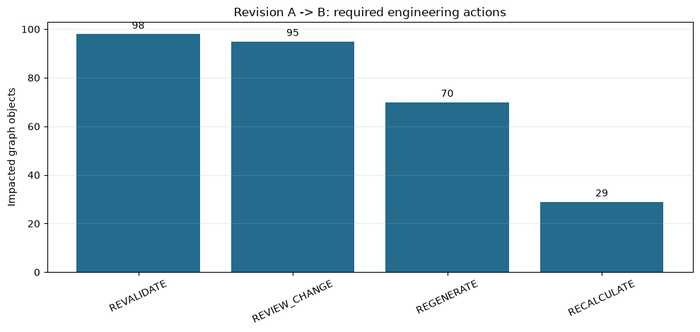

In [18]:
Instant = JClass('java.time.Instant')
ModelChangeEvent = JClass('neqsim.process.processmodel.lifecycle.event.ModelChangeEvent')
EventBus = JClass('neqsim.process.processmodel.lifecycle.event.InMemoryModelChangeEventBus')
EventJournal = JClass('neqsim.process.processmodel.lifecycle.event.ModelChangeEventJournal')
EventSubscriber = JClass('neqsim.process.processmodel.lifecycle.event.ModelChangeEventSubscriber')
ImpactAnalyzer = JClass('neqsim.process.engineering.impact.GeneralizedImpactAnalyzer')
EngineeringIds = JClass('neqsim.process.engineering.model.EngineeringIds')
EngineeringNodeKind = JClass('neqsim.process.engineering.model.EngineeringNode$Kind')

change_event = ModelChangeEvent.fromEngineeringGraphDiff(
    revision_diff, 'OFFSHORE-PROCESS-STUDY-A-B-001', 'OFFSHORE-PROCESS-STUDY:A->B',
    Instant.parse('2026-07-18T12:00:00Z'), 'NEQSIM_ENGINEERING_COMPILER',
    'PROCESS_ENGINEERING', 'OFFSHORE-PROCESS-STUDY', 'OFFSHORE-PROCESS-STUDY',
    'Add controlled 125% debottleneck case and regenerate coordinated deliverables')

delivered_event_ids = []
def receive_change(event):
    delivered_event_ids.append(str(event.getEventId()))
subscriber = JProxy(EventSubscriber, dict={'onModelChange': receive_change})
event_bus = EventBus(); event_bus.subscribe(subscriber)
first_publish = event_bus.publish(change_event)
duplicate_publish = event_bus.publish(change_event)

journal_path = revision_b_dir / 'model-change-events.jsonl'
journal_path.unlink(missing_ok=True)
journal = EventJournal(Paths.get(str(journal_path)))
journal_publish = journal.publish(change_event)
replayed_event_ids = []
def receive_replay(event):
    replayed_event_ids.append(str(event.getEventId()))
replay_subscriber = JProxy(EventSubscriber, dict={'onModelChange': receive_replay})
reloaded_journal = EventJournal(Paths.get(str(journal_path)))
replay_count = reloaded_journal.replay(replay_subscriber)

impact = ImpactAnalyzer().analyze(revised_graph, change_event)
(revision_b_dir / 'model-change-event.json').write_text(str(change_event.toJson()), encoding='utf-8')
(revision_b_dir / 'impact-analysis.json').write_text(str(impact.toJson()), encoding='utf-8')
impact_rows = []
for item in impact.getImpactedObjects():
    impact_rows.append({
        'node': str(item.getNodeId()), 'kind': str(item.getNodeKind()),
        'direct': item.isDirectChange(), 'depth': item.getPropagationDepth(),
        'actions': ', '.join(str(action) for action in item.getRequiredActions()),
        'path': ' -> '.join(str(node) for node in item.getPropagationPath()),
    })
impact_table = pd.DataFrame(impact_rows)
dexpi_artifacts = ['plant.dexpi.xml', 'plant-proteus.xml', 'plant-pydexpi.xml',
                   'engineering-dexpi-roundtrip-report.json']
dexpi_node_ids = [str(EngineeringIds.nodeId(EngineeringNodeKind.DOCUMENT, name))
                  for name in dexpi_artifacts]
dexpi_impact_table = impact_table[impact_table['node'].isin(dexpi_node_ids)].copy()
publish_table = pd.DataFrame([
    {'operation': 'first bus publish', 'status': str(first_publish.getStatus()),
     'deliveries': first_publish.getDeliveryCount()},
    {'operation': 'duplicate bus publish', 'status': str(duplicate_publish.getStatus()),
     'deliveries': duplicate_publish.getDeliveryCount()},
    {'operation': 'journal append', 'status': str(journal_publish.getStatus()), 'deliveries': 0},
    {'operation': 'journal reload + replay', 'status': 'REPLAYED', 'deliveries': replay_count},
])
display(publish_table); display(dexpi_impact_table)
print('Event fingerprint:', change_event.getPayloadFingerprint())
print('Impacted objects:', impact.getImpactedObjects().size(),
      'recalculation steps:', impact.getRecalculationOrder().size(),
      'reapproval actions:', impact.getReapprovalNodeIds().size())
assert str(first_publish.getStatus()) == 'PUBLISHED' and delivered_event_ids == [str(change_event.getEventId())]
assert str(duplicate_publish.getStatus()) == 'DUPLICATE'
assert replayed_event_ids == [str(change_event.getEventId())]
assert len(dexpi_impact_table) == len(dexpi_artifacts)
assert dexpi_impact_table['actions'].str.contains('REGENERATE').all()
assert dexpi_impact_table['actions'].str.contains('REVALIDATE').all()
assert not bool(impact.toMap().get('fitnessForConstruction'))

action_counts = {}
for item in impact.getImpactedObjects():
    for action in item.getRequiredActions():
        action_counts[str(action)] = action_counts.get(str(action), 0) + 1
action_counts = dict(sorted(action_counts.items(), key=lambda item: item[1], reverse=True))
fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.bar(action_counts.keys(), action_counts.values(), color='#246B8E')
ax.bar_label(bars, padding=3); ax.set_ylabel('Impacted graph objects')
ax.set_title('Revision A -> B: required engineering actions')
ax.tick_params(axis='x', rotation=25); ax.grid(axis='y', alpha=0.25)
fig.tight_layout(); plt.show()


**Figure discussion — lifecycle impact.** Observation: one controlled throughput addition changes more than its design-case row. The canonical graph makes the fan-out explicit and assigns regeneration, recalculation, revalidation, and reapproval work to the affected objects. The four DEXPI deliverables are shown separately above with their propagation paths. Interpretation: this is a work proposal and traceability record, not automatic acceptance; every regenerated engineering result remains review-required.


## 9. Verify and render the exported DEXPI package with PyDEXPI

The namespace-free `plant-pydexpi.xml` is loaded by the independent PyDEXPI `ProteusSerializer`, then rendered with `DrawDiagram` using the graphical information carried by the export. The genuine-symbol full-width SVG is divided into four readable review panels without redrawing or altering its contents; high-resolution PNG previews keep the executed notebook compact. The full drawing, SVG panels, PNG previews, and a machine-readable import/render report are added to revision B before the model-package inventory is refreshed, so they receive the same SHA-256 integrity protection as the XML and engineering registers. PyDEXPI import is an interoperability gate; it does not replace DEXPI 2.0 validation or a named commercial-CAE round trip.


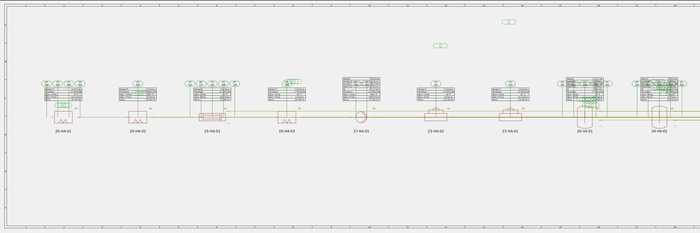

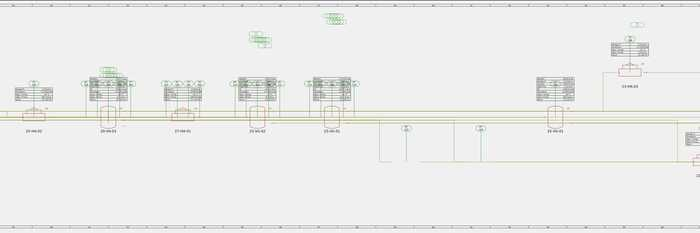

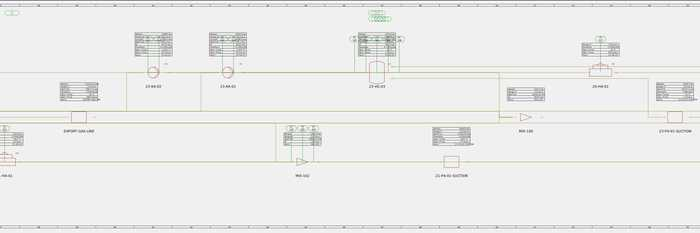

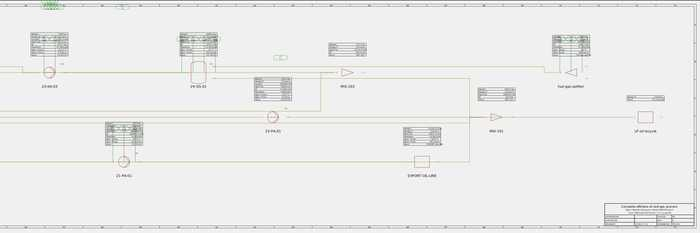

PyDEXPI import/render: IMPORT_AND_RENDER_PASSED | diagram groups: 305 | SVG bytes: 560204


,artifact,role,revision A SHA-256,revision B SHA-256,changed or added,revision B bytes
0,plant.dexpi.xml,EXCHANGE_MODEL,b208ef647ef7f3aa,b208ef647ef7f3aa,False,1117037
1,plant-proteus.xml,EXCHANGE_MODEL,995574d541dda370,67c8963044449b2c,True,2647851
2,plant-pydexpi.xml,EXCHANGE_MODEL,ceca6204684f59b3,0fee0acb9d3df829,True,2647665
3,engineering-dexpi-roundtrip-report.json,ENGINEERING_ARTIFACT,469fd9e5419eb3eb,0897a9870e550d7a,True,13008
4,model-change-event.json,ENGINEERING_ARTIFACT,—,5c1cfd075780fa1d,True,40549
5,model-change-events.jsonl,SUPPORTING_ARTIFACT,—,6a9df9d094b6f560,True,32377
6,impact-analysis.json,ENGINEERING_ARTIFACT,—,7832004d619fb791,True,55737
7,pydexpi-render-report.json,ENGINEERING_ARTIFACT,—,be7734f2ef52bc1e,True,942
8,offshore-process-revision-b-pydexpi.svg,SUPPORTING_ARTIFACT,—,0cceabd14fa37924,True,560204
9,offshore-process-revision-b-pydexpi-panel-1.svg,SUPPORTING_ARTIFACT,—,6ce470ebfa88da13,True,591534


Final revision B package: 88 inventoried artifacts; integrity valid = True


In [19]:
from copy import deepcopy
import xml.etree.ElementTree as ET
import cairosvg
from IPython.display import Image, HTML
from pydexpi.loaders import ProteusSerializer
from pydexpi.loaders.svg_loader import DrawDiagram

pydexpi_xml = revision_b_dir / 'plant-pydexpi.xml'
pydexpi_model = ProteusSerializer().load(str(revision_b_dir), pydexpi_xml.name)
assert pydexpi_model.diagram is not None
pydexpi_render_name = 'offshore-process-revision-b-pydexpi'
DrawDiagram(pydexpi_model.diagram, padding=5.0, pretty=True).save_svg(
    pydexpi_render_name, str(revision_b_dir))
pydexpi_svg = revision_b_dir / f'{pydexpi_render_name}.svg'
assert pydexpi_svg.is_file() and pydexpi_svg.stat().st_size > 0
diagram_groups = len(getattr(pydexpi_model.diagram, 'groups', []))
display(HTML(f'<p><b>Complete PyDEXPI rendering:</b> {pydexpi_svg.name} '             f'({pydexpi_svg.stat().st_size:,} bytes)</p>'))

# Keep the exact PyDEXPI drawing and create four viewBox-only review panels.
# Every symbol, line and tag still comes from DrawDiagram; only the viewport changes.
svg_tree = ET.parse(pydexpi_svg)
svg_root = svg_tree.getroot()
view_x, view_y, view_width, view_height = map(float, svg_root.attrib['viewBox'].split())
panel_titles = ['Separation and oil stabilization', 'LP/MP gas recovery',
                'Export compression and cooling', 'LTS, fuel gas and export']
pydexpi_panel_paths, pydexpi_panel_png_paths = [], []
for panel_index, panel_title in enumerate(panel_titles, start=1):
    panel_root = deepcopy(svg_root)
    panel_width = view_width / len(panel_titles)
    panel_x = view_x + (panel_index - 1) * panel_width
    panel_root.set('viewBox', f'{panel_x} {view_y} {panel_width} {view_height}')
    panel_root.set('width', '960'); panel_root.set('height', '320')
    background = next((child for child in panel_root if child.tag.endswith('rect')), None)
    if background is not None:
        background.set('x', str(panel_x)); background.set('y', str(view_y))
        background.set('width', str(panel_width)); background.set('height', str(view_height))
    panel_path = revision_b_dir / f'{pydexpi_render_name}-panel-{panel_index}.svg'
    ET.ElementTree(panel_root).write(panel_path, encoding='utf-8', xml_declaration=True)
    pydexpi_panel_paths.append(panel_path)
    panel_png_path = panel_path.with_suffix('.png')
    cairosvg.svg2png(url=str(panel_path), write_to=str(panel_png_path), output_width=1600)
    pydexpi_panel_png_paths.append(panel_png_path)
    display(HTML(f'<h4>{panel_index}. {panel_title}</h4>'))
    display(Image(filename=str(panel_png_path)))
assert all(path.is_file() and path.stat().st_size > 0 for path in pydexpi_panel_paths)
assert all(path.is_file() and path.stat().st_size > 0 for path in pydexpi_panel_png_paths)
pydexpi_report = {
    'schemaVersion': 'neqsim_pydexpi_render_report.v1',
    'sourceArtifact': pydexpi_xml.name, 'status': 'IMPORT_AND_RENDER_PASSED',
    'importer': 'pyDEXPI ProteusSerializer', 'renderer': 'pyDEXPI DrawDiagram',
    'diagramGroupCount': diagram_groups, 'renderedArtifact': pydexpi_svg.name,
    'reviewPanelSvgArtifacts': [path.name for path in pydexpi_panel_paths],
    'reviewPanelPngArtifacts': [path.name for path in pydexpi_panel_png_paths],
    'fitnessForConstruction': False,
    'governance': 'Third-party import and rendering do not grant engineering approval',
}
(revision_b_dir / 'pydexpi-render-report.json').write_text(
    json.dumps(pydexpi_report, indent=2) + '\n', encoding='utf-8')
print('PyDEXPI import/render:', pydexpi_report['status'],
      '| diagram groups:', diagram_groups, '| SVG bytes:', pydexpi_svg.stat().st_size)

package_b_before_refresh = NeqSimModelPackage.read(compiled_b.getModelPackageFile())
NeqSimModelPackage.write(Paths.get(str(revision_b_dir)), package_b_before_refresh.getIdentity(),
    package_b_before_refresh.getGraphArtifact(), package_b_before_refresh.getQualificationStatus(),
    package_b_before_refresh.getDependencies(), package_b_before_refresh.getSoftwareVersions())
package_b = NeqSimModelPackage.read(Paths.get(str(revision_b_dir / 'neqsim-model-package.json')))
package_b_validation = ModelPackageValidator.validate(Paths.get(str(revision_b_dir)))

def artifact_inventory(model_package):
    return {str(item.getPath()): item for item in model_package.getArtifacts()}
inventory_a, inventory_b = artifact_inventory(package_a), artifact_inventory(package_b)
lifecycle_artifacts = dexpi_artifacts + [
    'model-change-event.json', 'model-change-events.jsonl', 'impact-analysis.json',
    'pydexpi-render-report.json', pydexpi_svg.name,
    *[path.name for path in pydexpi_panel_paths],
    *[path.name for path in pydexpi_panel_png_paths]]
artifact_rows = []
for name in lifecycle_artifacts:
    before, after = inventory_a.get(name), inventory_b.get(name)
    artifact_rows.append({
        'artifact': name, 'role': str(after.getRole()) if after else '',
        'revision A SHA-256': str(before.getSha256())[:16] if before else '—',
        'revision B SHA-256': str(after.getSha256())[:16] if after else 'MISSING',
        'changed or added': before is None or str(before.getSha256()) != str(after.getSha256()),
        'revision B bytes': after.getSizeBytes() if after else 0,
    })
dexpi_package_table = pd.DataFrame(artifact_rows)
display(dexpi_package_table)
print('Final revision B package:', package_b.getArtifacts().size(), 'inventoried artifacts;',
      'integrity valid =', package_b_validation.isValid())
assert package_b_validation.isValid(), list(package_b_validation.getFindings())
assert all(name in inventory_b for name in lifecycle_artifacts)
assert all(inventory_b[name].getRole() == 'EXCHANGE_MODEL' for name in dexpi_artifacts[:3])


**P&ID discussion — exported model, not a redrawn picture.** Every illustration above is rasterized from the one PyDEXPI SVG rendering of revision B's governed Proteus exchange file. The retained full SVG proves that the third-party parser and renderer resolve the complete export; four viewBox-only panels make the very wide offshore train readable without changing symbols, tags, lines, or topology. PNG is used only for compact inline presentation. Reviewers can inspect separation/oil stabilization, gas recovery, compression/cooling, and LTS/export areas at useful scale. This visual check does not qualify the package for construction or prove round-trip fidelity in the project's target CAE system.


## HAZOP-ready detailed P&ID package

The complete proposal profile adds control, isolation, shutdown, blowdown, non-return, drain, vent and relief functions. HAZOP nodes are generated from this exact P&ID-backed model and fail readiness if an equipment node or element reference is unresolved.

In [20]:
PidBasis = JClass('neqsim.process.engineering.pid.PidDesignBasis')
PidCatalog = JClass('neqsim.process.engineering.pid.NorsokPidRuleCatalog')
PidSynthesizer = JClass('neqsim.process.engineering.pid.PidDesignSynthesizer')
PidExporter = JClass('neqsim.process.engineering.pid.PidEngineeringPackageExporter')
ProtectedItem = JClass('neqsim.process.safety.overpressure.ProtectedItem')
ReliefScenario = JClass('neqsim.process.safety.overpressure.ReliefScenario')
ReliefCause = JClass('neqsim.process.safety.overpressure.ReliefCause')
ReliefPhase = JClass('neqsim.process.safety.overpressure.ReliefPhase')
OverpressureStudy = JClass('neqsim.process.safety.overpressure.OverpressureProtectionStudy')
ReliefInput = JClass('neqsim.process.engineering.ReliefDeviceDesignInput')
protected = ProtectedItem('20-VA-01', 45.0).setReliefSetPressureBara(43.0)
scenario = ReliefScenario.Builder('HP separator blocked gas outlet', ReliefCause.BLOCKED_OUTLET).phase(ReliefPhase.VAPOUR).reliefRateKgPerS(18.0).reliefTemperatureK(343.15).molarMassKgPerMol(0.022).compressibility(0.93).specificHeatRatio(1.24).build()
project.addOverpressureStudy(OverpressureStudy(protected).addScenario(scenario))
project.addReliefDeviceDesignInput(ReliefInput('20-PSV-101', '20-VA-01').setSelectedOrificeAreaIn2(11.05).setInletPiping(0.10, 3.0, 2.0).setOutletPiping(0.20, 35.0, 5.0).setConcurrencyGroup('FIRE-ZONE-20').setEvidenceReference('PRELIMINARY-PSV-DESIGN-CASE'))
pid = PidSynthesizer.synthesize(project, PidBasis('NORSOK-COMPLETE-PID-PROPOSALS', '20'), PidCatalog.completeProposals())
advanced_dir = package_root / 'revision-b' / 'ncs-hazop-safety-study'
advanced_dir.mkdir(parents=True, exist_ok=True)
pid_export = PidExporter.export(project, pid, Paths.get(str(advanced_dir)))
hazop = json.loads((advanced_dir / 'pid-hazop-study.json').read_text(encoding='utf-8'))
pid_json = json.loads((advanced_dir / 'pid-design-model.json').read_text(encoding='utf-8'))
print('P&ID elements:', len(pid_json['elements']), '| HAZOP nodes:', len(hazop['nodes']), '| ready:', hazop['readyForHazopWorkshop'])
assert hazop['readyForHazopWorkshop'] and len(pid_json['elements']) > 100

using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using default mechanical design standards...no design standard default
using 

P&ID elements: 445 | HAZOP nodes: 37 | ready: True


## Dynamic ESD and HIPPS final-element tests with SIL evaluation

The isolation tests use NeqSim transient execution and the same representative HP wellstream fluid. The HIPPS SIF separately records 2oo3 voting, SIL 3 PFDavg and proof-test assumptions. A successful simulation is evidence for response-time and pressure criteria only; it does not prove IEC 61511 compliance.

In [21]:
ESDValve = JClass('neqsim.process.equipment.valve.ESDValve')
ESDLogic = JClass('neqsim.process.logic.esd.ESDLogic')
TripValveAction = JClass('neqsim.process.logic.action.TripValveAction')
TagMap = JClass('neqsim.process.operations.OperationalTagMap')
TagBinding = JClass('neqsim.process.operations.OperationalTagBinding')
TagRole = JClass('neqsim.process.measurementdevice.InstrumentTagRole')
TestPlan = JClass('neqsim.process.safety.esd.EmergencyShutdownTestPlan')
Criterion = JClass('neqsim.process.safety.esd.EmergencyShutdownTestCriterion')
TestRunner = JClass('neqsim.process.safety.esd.EmergencyShutdownTestRunner')
SafetyFunction = JClass('neqsim.process.safety.risk.sis.SafetyInstrumentedFunction')
SifCategory = JClass('neqsim.process.safety.risk.sis.SafetyInstrumentedFunction$SIFCategory')
TransientVerification = JClass('neqsim.process.engineering.safety.SafetyFunctionTransientVerification')
NcsStudy = JClass('neqsim.process.engineering.safety.NcsSafetyFunctionStudy')

def shutdown_test(name, stroke_time):
    feed = Stream(name + '-feed', process.getUnit('well stream').getThermoSystem().clone())
    feed.setFlowRate(BASE['feed_rate_kmol_h'] * 1000.0 / 3600.0, 'mol/sec'); feed.setPressure(BASE['Psep1_barg'] + 0.5, 'barg')
    valve = ESDValve(name + '-XV', feed); valve.setStrokeTime(stroke_time); valve.setCv(1500.0); valve.energize(); valve.setPercentValveOpening(100.0)
    vessel = Separator(name + '-HP-separator', valve.getOutletStream())
    dynamic_process = ProcessSystem(name); dynamic_process.add(feed); dynamic_process.add(valve); dynamic_process.add(vessel); dynamic_process.run()
    logic = ESDLogic(name); logic.addAction(TripValveAction(valve), 0.0)
    tags = TagMap().addBinding(TagBinding.builder('xv_opening').pidReference(name + '/XV').automationAddress(name + '-XV.percentValveOpening').unit('%').role(TagRole.BENCHMARK).build()).addBinding(TagBinding.builder('protected_pressure').pidReference(name + '/PT').automationAddress(name + '-HP-separator.gasOutStream.pressure').unit('bara').role(TagRole.BENCHMARK).build())
    plan = TestPlan.builder(name + ' dynamic isolation').duration(8.0).timeStep(0.5).tagMap(tags).enableLogic(name).triggerLogic(name).criterion(Criterion.finalAtMost(name + '-CLOSED', 'xv_opening', 1.0, '%').withClause('NORSOK S-001')).criterion(Criterion.maxAtMost(name + '-MAWP', 'protected_pressure', 45.0, 'bara').withClause('API 521 / NORSOK S-001')).criterion(Criterion.noSimulationErrors(name + '-NO-ERRORS')).standardReference('IEC 61511').evidenceReference('P&ID ' + name).build()
    return TestRunner.run(dynamic_process, plan, logic)

esd_result = shutdown_test('ESD-20-001', 4.0)
hipps_result = shutdown_test('HIPPS-20-001', 2.0)
(advanced_dir / 'esd-dynamic-test.json').write_text(str(esd_result.toJson()), encoding='utf-8')
(advanced_dir / 'hipps-dynamic-test.json').write_text(str(hipps_result.toJson()), encoding='utf-8')
samples = list(hipps_result.getTimeSeries())
times = [float(s.getTimeSeconds()) for s in samples]; pressure = [float(s.getValues().get('protected_pressure')) for s in samples]; opening = [float(s.getValues().get('xv_opening')) for s in samples]
dynamic_evidence = TransientVerification('SIF-HIPPS-20-001', 32.0, 45.0, 2.5).verify(jdouble(times), jdouble(pressure), jdouble(opening))
hipps_sif = SafetyFunction.builder().id('SIF-HIPPS-20-001').name('HP inlet HIPPS').description('Prevent HP separator overpressure').sil(3).pfd(5.0e-4).testIntervalHours(8760.0).mttr(24.0).addProtectedEquipment('20-VA-01').initiatingEvent('Blocked outlet or upstream control failure').safeState('Two series HIPPS isolation valves closed').category(SifCategory.HIPPS).architecture('2oo3').build()
esd_sif = SafetyFunction.builder().id('SIF-ESD-20-001').name('HP inlet ESD').description('Isolate HP production inlet').sil(2).pfd(5.0e-3).testIntervalHours(8760.0).mttr(24.0).addProtectedEquipment('20-VA-01').initiatingEvent('Confirmed process shutdown demand').safeState('Inlet ESD valve closed').category(SifCategory.ESD).architecture('1oo2').build()
study = NcsStudy(project.getProjectId()).add(hipps_sif, dynamic_evidence).add(esd_sif, dynamic_evidence)
(advanced_dir / 'ncs-safety-function-study.json').write_text(str(study.toJson()), encoding='utf-8')
print('ESD verdict:', esd_result.getVerdict(), '| HIPPS final-element verdict:', hipps_result.getVerdict(), '| transient criteria:', dict(dynamic_evidence))
assert str(esd_result.getVerdict()) == 'PASS' and str(hipps_result.getVerdict()) == 'PASS' and bool(dynamic_evidence.get('passed'))

ESD verdict: PASS | HIPPS final-element verdict: PASS | transient criteria: {'schemaVersion': 'neqsim_safety_transient_verification.v1', 'functionId': 'SIF-HIPPS-20-001', 'tripSetPressureBara': 32.0, 'maximumAllowablePressureBara': 45.0, 'maximumSimulatedPressureBara': 33.01325, 'requiredClosureTimeSeconds': 2.5, 'actualClosureTimeSeconds': 2.0, 'tripDetected': True, 'pressureCriterionPassed': True, 'closureCriterionPassed': True, 'passed': True, 'status': 'DYNAMIC_MODEL_VERIFICATION_REVIEW_REQUIRED', 'standardReferences': <java object 'java.util.Arrays.ArrayList'>}


## Professional PyDEXPI review sheets

The images below are rendered by PyDEXPI from the exported exchange model. Valve symbols are DEXPI piping components; instruments and safety functions retain proposal identity and approval state.

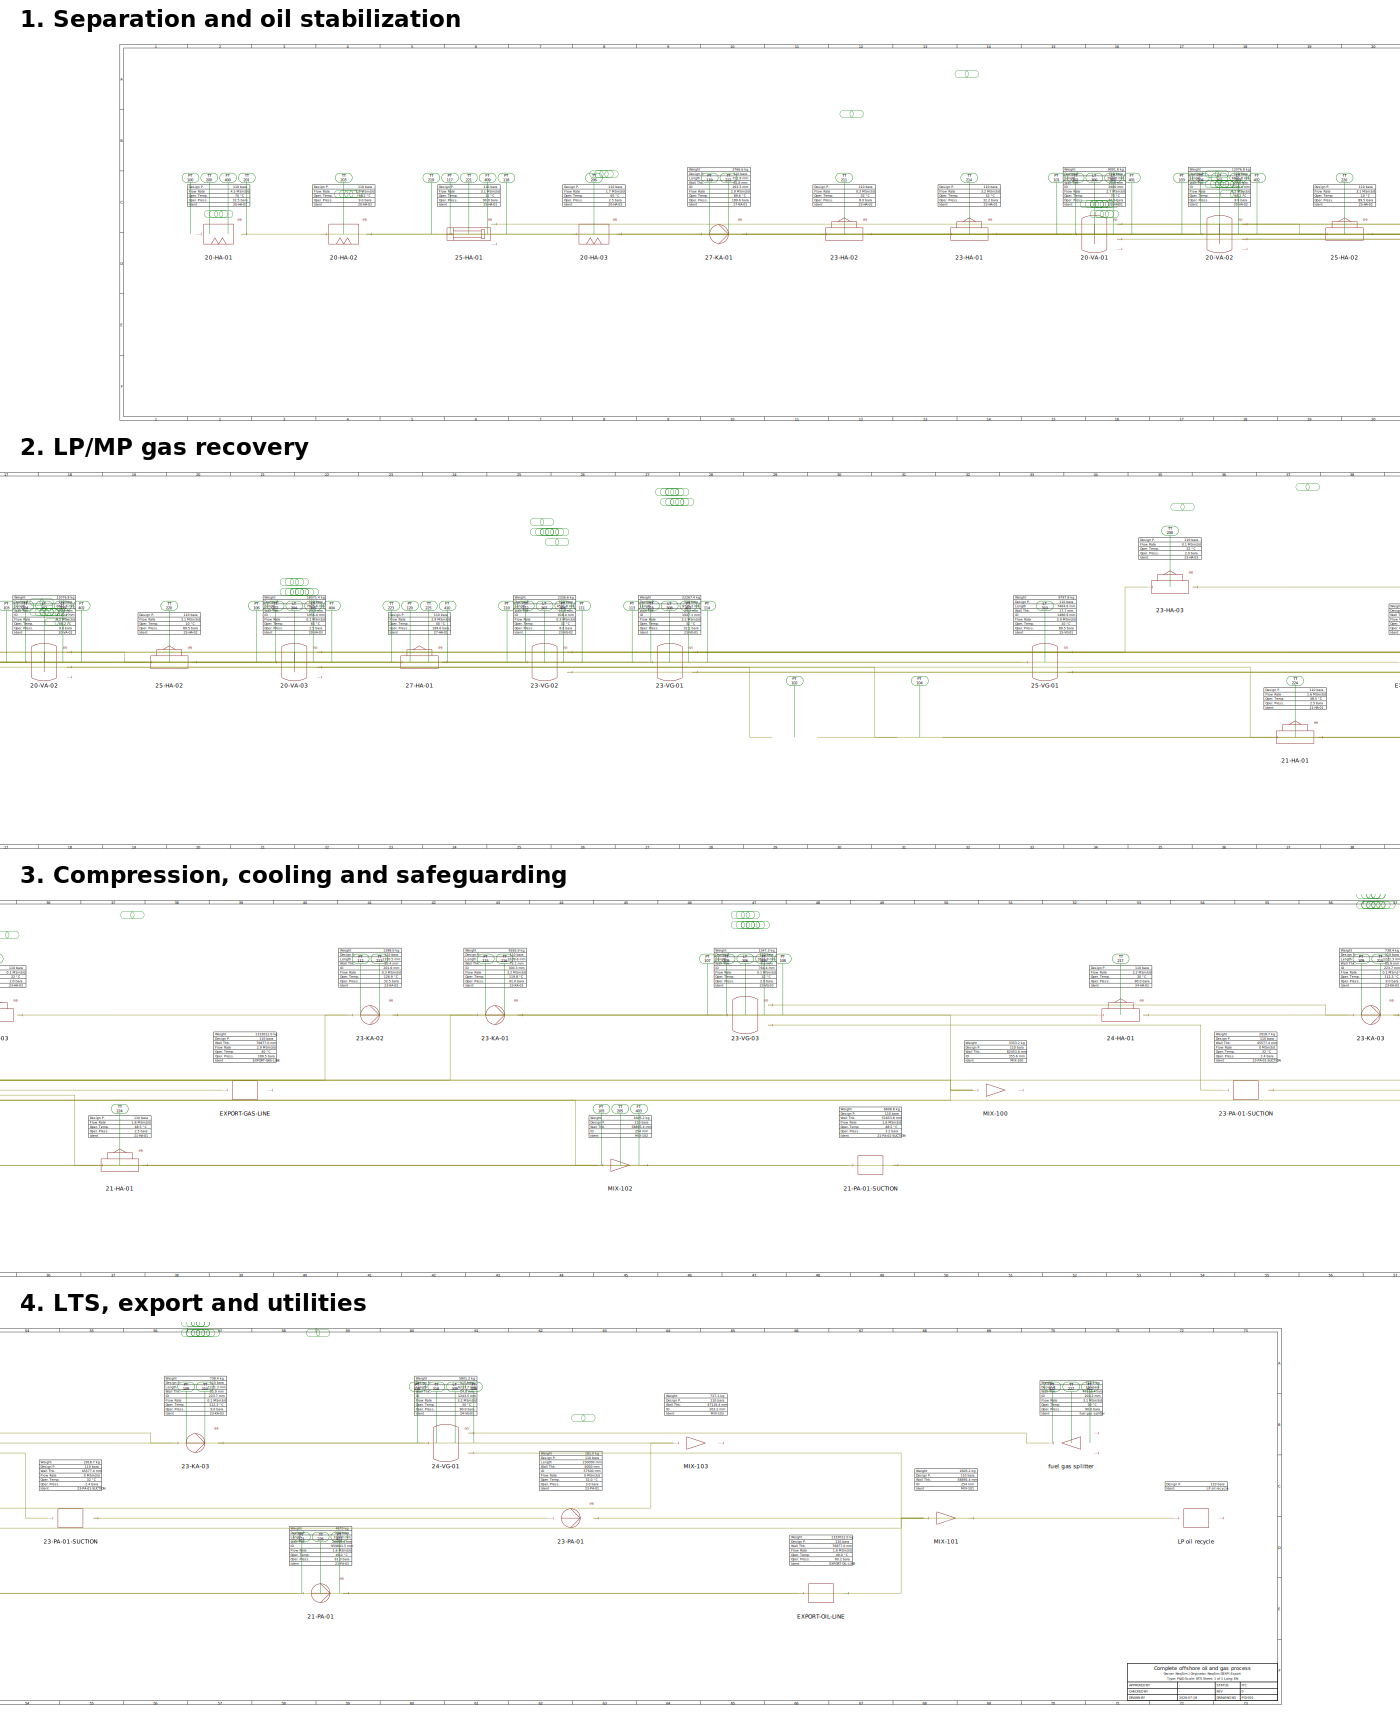

PyDEXPI groups: 627 | SVG bytes: 596586


In [22]:
from copy import deepcopy
import xml.etree.ElementTree as ET
from IPython.display import SVG
advanced_model = ProteusSerializer().load(str(advanced_dir), 'plant-pydexpi.xml')
DrawDiagram(advanced_model.diagram, padding=5.0, pretty=True).save_svg('ncs-detailed-pid', str(advanced_dir))
advanced_svg = advanced_dir / 'ncs-detailed-pid.svg'

# The complete train is very wide. Build one efficient SVG review sheet containing four
# enlarged viewBox panels while retaining a single copy of the PyDEXPI drawing content.
svg_root = ET.parse(advanced_svg).getroot()
svg_namespace = 'http://www.w3.org/2000/svg'
ET.register_namespace('', svg_namespace)
view_x, view_y, view_width, view_height = map(float, svg_root.attrib['viewBox'].split())
panel_titles = ['Separation and oil stabilization', 'LP/MP gas recovery',
                'Compression, cooling and safeguarding', 'LTS, export and utilities']
sheet_width, panel_height, title_height = 1400, 390, 38
sheet_height = len(panel_titles) * (panel_height + title_height)
review_root = ET.Element(f'{{{svg_namespace}}}svg', {
    'width': str(sheet_width), 'height': str(sheet_height),
    'viewBox': f'0 0 {sheet_width} {sheet_height}'})
definitions = ET.SubElement(review_root, f'{{{svg_namespace}}}defs')
drawing_content = ET.SubElement(definitions, f'{{{svg_namespace}}}g', {'id': 'complete-pid-content'})
for child in list(svg_root):
    if child.tag.endswith('g'):
        drawing_content.append(deepcopy(child))
panel_width = view_width / len(panel_titles)
for panel_index, panel_title in enumerate(panel_titles):
    panel_top = panel_index * (panel_height + title_height)
    panel_x = view_x + panel_index * panel_width
    title = ET.SubElement(review_root, f'{{{svg_namespace}}}text', {
        'x': '20', 'y': str(panel_top + 27), 'font-size': '23', 'font-weight': 'bold'})
    title.text = f'{panel_index + 1}. {panel_title}'
    panel = ET.SubElement(review_root, f'{{{svg_namespace}}}svg', {
        'x': '0', 'y': str(panel_top + title_height), 'width': str(sheet_width),
        'height': str(panel_height), 'viewBox': f'{panel_x} {view_y} {panel_width} {view_height}',
        'preserveAspectRatio': 'xMidYMid meet'})
    ET.SubElement(panel, f'{{{svg_namespace}}}rect', {
        'x': str(panel_x), 'y': str(view_y), 'width': str(panel_width),
        'height': str(view_height), 'fill': 'white'})
    ET.SubElement(panel, f'{{{svg_namespace}}}use', {'href': '#complete-pid-content'})
review_svg = advanced_dir / 'ncs-detailed-pid-review-panels.svg'
ET.ElementTree(review_root).write(review_svg, encoding='utf-8', xml_declaration=True)
display(SVG(filename=str(review_svg)))
outputs = sorted(p.name for p in advanced_dir.iterdir() if p.is_file())
display(pd.DataFrame({'generated artifact': outputs}))
print('PyDEXPI groups:', len(getattr(advanced_model.diagram, 'groups', [])), '| SVG bytes:', advanced_svg.stat().st_size)
assert advanced_svg.stat().st_size > 0 and review_svg.stat().st_size > 0
assert 'pid-hazop-study.json' in outputs and 'ncs-safety-function-study.json' in outputs

## Reviewable engineering deliverables and generated-artifact index

This final report section inventories **every generated file** and exposes the useful engineering content directly in the notebook. Registers are shown with row counts and readable previews; JSON studies are summarized by status and collection size; HAZOP nodes and dynamic safety results receive dedicated tables; DEXPI/XML files remain available unchanged in the uploaded package. The previews are for engineering review and do not replace controlled native deliverables.


In [23]:
from IPython.display import HTML, display

all_artifacts = sorted(path for path in advanced_dir.rglob('*') if path.is_file())
artifact_link_root = '../complete-offshore-process-engineering-study/revision-b/ncs-hazop-safety-study'
def artifact_link(relative):
    return f'<a href="{artifact_link_root}/{relative}" target="_blank">open file</a>'
artifact_rows = []
for path in all_artifacts:
    relative = path.relative_to(advanced_dir)
    suffix = path.suffix.lower()
    category = ('REGISTER' if 'registers' in relative.parts else
                'DEXPI_OR_XML' if suffix == '.xml' else
                'P_AND_ID' if suffix == '.svg' else
                'TABULAR' if suffix == '.csv' else
                'ENGINEERING_JSON' if suffix == '.json' else 'OTHER')
    artifact_rows.append({
        'artifact': str(relative), 'open': artifact_link(relative), 'category': category,
        'format': suffix.lstrip('.').upper(), 'bytes': path.stat().st_size})
artifact_index = pd.DataFrame(artifact_rows)
display(HTML('<h3>Complete generated-artifact index</h3>'))
display(HTML('<p>Links resolve when the executed-notebook artifact ZIP is extracted with its generated engineering package.</p>'))
display(HTML(artifact_index.to_html(index=False, escape=False)))
print('Indexed generated files:', len(artifact_index), '| total bytes:', int(artifact_index['bytes'].sum()))

register_paths = sorted((advanced_dir / 'registers').glob('*.csv'))
register_summary = []
for register_path in register_paths:
    register = pd.read_csv(register_path)
    register_summary.append({'register': register_path.name, 'rows': len(register),
                             'columns': len(register.columns)})
    register_relative = register_path.relative_to(advanced_dir)
    display(HTML(f'<h4>{register_path.stem.replace("-", " ").title()} '
                 f'— {len(register)} rows (first 25 shown) — '
                 f'{artifact_link(register_relative)}</h4>'))
    display(register.head(25))
display(HTML('<h3>Register coverage summary</h3>'))
display(pd.DataFrame(register_summary))

json_summary = []
json_payloads = {}
for json_path in sorted(advanced_dir.glob('*.json')):
    payload = json.loads(json_path.read_text(encoding='utf-8'))
    json_payloads[json_path.name] = payload
    scalar_status = ''
    collection_counts = []
    if isinstance(payload, dict):
        for key in ('status', 'verdict', 'qualificationStatus', 'readyForHazopWorkshop',
                    'fitForConstruction'):
            if key in payload:
                scalar_status += f'{key}={payload[key]} '
        for key, value in payload.items():
            if isinstance(value, (list, dict)):
                collection_counts.append(f'{key}:{len(value)}')
    json_summary.append({'artifact': json_path.name, 'open': artifact_link(json_path.name),
                         'status': scalar_status.strip(),
                         'collections': ', '.join(collection_counts[:8]),
                         'bytes': json_path.stat().st_size})
display(HTML('<h3>Engineering JSON study and validation summary</h3>'))
display(HTML(pd.DataFrame(json_summary).to_html(index=False, escape=False)))

hazop_payload = json_payloads['pid-hazop-study.json']
hazop_rows = []
for node in hazop_payload.get('nodes', []):
    hazop_rows.append({
        'node': node.get('nodeId'), 'equipment': node.get('equipmentTag'),
        'equipment type': node.get('equipmentType'),
        'P&ID elements': len(node.get('pidElementTags', [])),
        'deviations': len(node.get('deviations', []))})
display(HTML('<h3>P&ID-backed HAZOP node coverage</h3>'))
display(pd.DataFrame(hazop_rows))

safety_rows = []
for result_name in ('esd-dynamic-test.json', 'hipps-dynamic-test.json'):
    result = json_payloads[result_name]
    safety_rows.append({
        'test': result_name.replace('-dynamic-test.json', '').upper(),
        'verdict': result.get('verdict'), 'duration s': result.get('durationSeconds'),
        'time step s': result.get('timeStepSeconds'),
        'criteria': len(result.get('criterionResults', result.get('criteria', []))),
        'samples': len(result.get('timeSeries', []))})
display(HTML('<h3>Dynamic ESD and HIPPS test evidence</h3>'))
display(pd.DataFrame(safety_rows))

xml_rows = []
for xml_path in sorted(advanced_dir.glob('*.xml')):
    root = ET.parse(xml_path).getroot()
    xml_rows.append({'artifact': xml_path.name, 'open': artifact_link(xml_path.name),
                     'root element': root.tag,
                     'XML elements': sum(1 for _ in root.iter()), 'bytes': xml_path.stat().st_size})
display(HTML('<h3>DEXPI and Proteus exchange deliverables</h3>'))
display(HTML(pd.DataFrame(xml_rows).to_html(index=False, escape=False)))

assert len(artifact_index) == len(all_artifacts)
assert set(path.name for path in register_paths) >= {
    'equipment-register.csv', 'line-list.csv', 'valve-list.csv', 'instrument-index.csv',
    'shutdown-register.csv', 'relief-register.csv', 'sif-register.csv'}
assert not pd.DataFrame(hazop_rows).empty and len(xml_rows) >= 3


artifact,open,category,format,bytes
cause-and-effect.json,open file,ENGINEERING_JSON,JSON,40827
dexpi-validation.json,open file,ENGINEERING_JSON,JSON,532
engineering-calculations.json,open file,ENGINEERING_JSON,JSON,1143567
engineering-manifest.json,open file,ENGINEERING_JSON,JSON,749249
esd-dynamic-test.json,open file,ENGINEERING_JSON,JSON,4663
hipps-dynamic-test.json,open file,ENGINEERING_JSON,JSON,4671
interoperability-report.json,open file,ENGINEERING_JSON,JSON,782
ncs-detailed-pid-review-panels.svg,open file,P_AND_ID,SVG,597742
ncs-detailed-pid.svg,open file,P_AND_ID,SVG,596586
ncs-safety-function-study.json,open file,ENGINEERING_JSON,JSON,4945


Indexed generated files: 26 | total bytes: 12402184


## 10. Engineering conclusions

The normal case reproduces the published process benchmark: approximately 5,112 kmol/h export gas, 2,753 kmol/h export oil, 10.25 psia oil RVP, 45.68 MJ/Sm3 gas GCV, 53.49 MJ/Sm3 Wobbe index, and 10.38 MW total compressor-plus-oil-pump power. The connected design loop identifies the governing case separately for separator geometry, inventory, exchanger area, line diameter, valve Cv, and driver rating. Discipline tables then expose preliminary separator, compressor, pump, exchanger, piping, valve/instrument, relief/blowdown/flare, materials, and mechanical results for the full train.

The revision A-to-B lifecycle demonstrates the new repository capabilities as one connected workflow: `NeqSimModelPackage` v1 gives the model and exported DEXPI files stable revision identity and content integrity; the change-event bus and journal make the revision notification idempotent and replayable; and the generalized impact engine converts the graph difference into traceable regeneration, recalculation, revalidation, and reapproval work. PyDEXPI independently imports and renders the governed compatibility XML, and the full drawing plus four readable SVG/PNG panel pairs are inventoried in revision B.

The package is a reproducible concept/pre-FEED engineering basis, not a construction design. Before project use, replace every screening assumption with controlled inputs and close the generated actions for fluid validation, HAZOP/LOPA/SRS, compressor and pump maps, exchanger vendor thermal design, two-phase relief method, flare-network/consequence analysis, piping stress and transients, valve noise/cavitation and actuator sizing, instrument installation/thermowells, corrosion/materials approval, pressure-vessel code design, layout/maintainability, target-CAE DEXPI round trip, and accountable release.
